# Age Detection Pipeline: Under-18 vs Adult Classification

## Complete Pipeline with Maximum Image Size (584×584) and DDP

**Configuration:**
- **Image Size:** 584×584 (Maximum for EfficientNet-B3)
- **Model:** EfficientNet-B3 (Pre-trained on ImageNet)
- **Training:** Distributed Data Parallel (DDP) for multi-GPU
- **Dataset:** UTKFace (23,708 images)
- **Task:** Binary Classification (Under-18 vs Adult)
- **Primary Metric:** Under-18 Recall (minimize false negatives)

---


## Step 1: Environment Setup & Library Imports


In [1]:
# ============================================================
# STEP 1: ENVIRONMENT SETUP & LIBRARY IMPORTS
# ============================================================

# Core Python libraries
import os
import sys
import time
import copy
from collections import defaultdict

# Data manipulation
import pandas as pd
import numpy as np

# Image processing
from PIL import Image
import cv2

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Distributed training
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler

# Torchvision
import torchvision
from torchvision import transforms, models
import torchvision.utils as vutils

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Progress bars
from tqdm.notebook import tqdm

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# Better plot quality
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*60)
print("✓ All libraries imported successfully")
print("="*60)


✓ All libraries imported successfully


## Step 2: GPU Configuration & DDP Setup


In [2]:
# ============================================================
# STEP 2: GPU CONFIGURATION & DDP SETUP
# ============================================================

print("="*60)
print("GPU CONFIGURATION")
print("="*60)

if not torch.cuda.is_available():
    print("❌ CUDA not available! Check GPU settings.")
    sys.exit()

print(f"✓ CUDA Available: {torch.cuda.is_available()}")
print(f"✓ PyTorch Version: {torch.__version__}")
print(f"✓ CUDA Version: {torch.version.cuda}")
print(f"✓ Number of GPUs: {torch.cuda.device_count()}")

for i in range(torch.cuda.device_count()):
    props = torch.cuda.get_device_properties(i)
    print(f"\nGPU {i}: {torch.cuda.get_device_name(i)}")
    print(f"  Total Memory: {props.total_memory / 1e9:.2f} GB")
    print(f"  CUDA Capability: {props.major}.{props.minor}")
    print(f"  Multi-Processors: {props.multi_processor_count}")

# DDP Setup
def setup_ddp():
    """
    Initialize distributed training
    
    For Kaggle notebooks:
    - If DDP env vars exist, use proper DDP
    - If multiple GPUs detected but no env vars, use DataParallel (notebook-friendly)
    - Otherwise use single GPU
    """
    num_gpus = torch.cuda.device_count()
    
    # Check if DDP environment variables are set (proper DDP mode)
    if 'RANK' in os.environ and 'WORLD_SIZE' in os.environ and 'LOCAL_RANK' in os.environ:
        rank = int(os.environ['RANK'])
        world_size = int(os.environ['WORLD_SIZE'])
        local_rank = int(os.environ['LOCAL_RANK'])
        use_ddp = True
        
        if world_size > 1:
            dist.init_process_group(
                backend='nccl',
                init_method='env://'
            )
            torch.cuda.set_device(local_rank)
            device = torch.device(f'cuda:{local_rank}')
            print(f"\n✓ DDP Initialized: Rank {rank}/{world_size-1}, Local Rank {local_rank}")
        else:
            device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
            use_ddp = False
            print(f"\n✓ Single GPU Mode: {device}")
    else:
        # No DDP env vars - check if we have multiple GPUs
        if num_gpus > 1:
            # Use DataParallel for notebook compatibility
            rank = 0
            world_size = num_gpus  # For LR scaling purposes
            local_rank = 0
            use_ddp = False  # Will use DataParallel instead
            device = torch.device("cuda:0")
            print(f"\n✓ Multiple GPUs detected ({num_gpus}) but DDP env vars not set")
            print(f"  Will use DataParallel for multi-GPU training (notebook-friendly)")
            print(f"  For proper DDP, run with: torchrun or python -m torch.distributed.launch")
        else:
            # Single GPU
            rank = 0
            world_size = 1
            local_rank = 0
            use_ddp = False
            device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
            print(f"\n✓ Single GPU Mode: {device}")
    
    return device, rank, world_size, local_rank, use_ddp

device, rank, world_size, local_rank, use_ddp = setup_ddp()

# Set primary device for non-distributed operations
if world_size == 1:
    primary_device = device
else:
    primary_device = torch.device(f'cuda:{local_rank}')

print(f"✓ Primary device: {primary_device}")
print(f"✓ Training will use: {'DDP' if use_ddp else ('DataParallel' if world_size > 1 else 'Single GPU')}")
print("="*60)


GPU CONFIGURATION
✓ CUDA Available: True
✓ PyTorch Version: 2.6.0+cu124
✓ CUDA Version: 12.4
✓ Number of GPUs: 2

GPU 0: Tesla T4
  Total Memory: 15.83 GB
  CUDA Capability: 7.5
  Multi-Processors: 40

GPU 1: Tesla T4
  Total Memory: 15.83 GB
  CUDA Capability: 7.5
  Multi-Processors: 40

✓ Multiple GPUs detected (2) but DDP env vars not set
  Will use DataParallel for multi-GPU training (notebook-friendly)
  For proper DDP, run with: torchrun or python -m torch.distributed.launch
✓ Primary device: cuda:0
✓ Training will use: DataParallel


## Step 3: Project Configuration


In [3]:
# ============================================================
# STEP 3: PROJECT CONFIGURATION
# ============================================================

class Config:
    """Centralized configuration"""
    
    # Paths - UTKFace dataset has two directories
    DATASET_PATH_1 = '/kaggle/input/utkface-new/UTKFace'
    DATASET_PATH_2 = '/kaggle/input/utkface-new/crop_part1'
    OUTPUT_DIR = '/kaggle/working/'
    
    # Random seed
    RANDOM_SEED = 42
    
    # Image settings - MAXIMUM SIZE
    IMAGE_SIZE = 584  # Maximum practical size for EfficientNet-B3
    
    # Model settings
    MODEL_NAME = 'efficientnet_b3'
    NUM_CLASSES = 2  # Under-18 vs Adult
    PRETRAINED = True
    
    # Training settings
    BATCH_SIZE = 32  # Per GPU (reduced for 584×584)
    NUM_EPOCHS = 60
    BASE_LEARNING_RATE = 0.001  # Base LR for single GPU
    WEIGHT_DECAY = 0.0001
    
    def __init__(self, num_gpus=1):
        """
        Initialize config with GPU-aware learning rate scaling
        
        Args:
            num_gpus: Number of GPUs (for LR scaling)
            
        Note:
            Learning rate is scaled linearly with number of GPUs.
            This follows the linear scaling rule: LR = base_lr × num_gpus
            This maintains the same effective learning rate per sample when
            using distributed training with larger effective batch sizes.
            
            Example:
                - 1 GPU:  LR = 0.001 × 1 = 0.001
                - 2 GPUs: LR = 0.001 × 2 = 0.002
                - 4 GPUs: LR = 0.001 × 4 = 0.004
        """
        # Scale learning rate linearly with number of GPUs
        # Linear scaling rule: LR = base_lr * num_gpus
        # This maintains the same effective learning rate per sample
        self.LEARNING_RATE = self.BASE_LEARNING_RATE * num_gpus
    
    # Data split
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    
    # DataLoader
    NUM_WORKERS = 4
    PIN_MEMORY = True
    
    # Optimizer & Scheduler
    OPTIMIZER = 'adamw'
    SCHEDULER = 'reduce_on_plateau'
    SCHEDULER_PATIENCE = 5
    SCHEDULER_FACTOR = 0.5
    SCHEDULER_MIN_LR = 1e-6
    
    # Early stopping
    EARLY_STOPPING_PATIENCE = 12
    
    # Mixed precision
    USE_AMP = True  # Automatic Mixed Precision (FP16)
    
    # Checkpointing
    SAVE_BEST_ONLY = True
    METRIC_TO_MONITOR = 'val_under18_recall'  # Primary metric
    
    # Class names
    CLASS_NAMES = ['under18', 'adult']
    
    # Age threshold
    AGE_THRESHOLD = 18

# Initialize config with GPU count for LR scaling
config = Config(num_gpus=world_size)

print("="*60)
print("PROJECT CONFIGURATION")
print("="*60)
print(f"Image Size: {config.IMAGE_SIZE}×{config.IMAGE_SIZE} (MAXIMUM)")
print(f"Model: {config.MODEL_NAME}")
print(f"Batch Size: {config.BATCH_SIZE} (per GPU)")
print(f"Total Batch Size: {config.BATCH_SIZE * world_size} (with {world_size} GPUs)")
print(f"Epochs: {config.NUM_EPOCHS}")
print(f"Base Learning Rate: {config.BASE_LEARNING_RATE}")
print(f"Scaled Learning Rate: {config.LEARNING_RATE} (×{world_size} for {world_size} GPU{'s' if world_size > 1 else ''})")
print(f"LR Scaling: Linear (LR = base_lr × num_gpus)")
print(f"Mixed Precision: {config.USE_AMP}")
training_mode = 'DDP' if (world_size > 1 and use_ddp) else ('DataParallel' if world_size > 1 else 'Single GPU')
print(f"Training Mode: {training_mode}")
print(f"Primary Metric: {config.METRIC_TO_MONITOR}")
print("="*60)


PROJECT CONFIGURATION
Image Size: 584×584 (MAXIMUM)
Model: efficientnet_b3
Batch Size: 32 (per GPU)
Total Batch Size: 64 (with 2 GPUs)
Epochs: 60
Base Learning Rate: 0.001
Scaled Learning Rate: 0.002 (×2 for 2 GPUs)
LR Scaling: Linear (LR = base_lr × num_gpus)
Mixed Precision: True
Training Mode: DataParallel
Primary Metric: val_under18_recall


## Step 4: Dataset Loading & Verification


In [4]:
# ============================================================
# STEP 4: DATASET LOADING & VERIFICATION
# ============================================================

print("="*60)
print("DATASET VERIFICATION")
print("="*60)

# Check both dataset paths
dataset_paths = []
if os.path.exists(config.DATASET_PATH_1):
    dataset_paths.append(config.DATASET_PATH_1)
    print(f"✓ Found: {config.DATASET_PATH_1}")
else:
    print(f"⚠ Not found: {config.DATASET_PATH_1}")

if os.path.exists(config.DATASET_PATH_2):
    dataset_paths.append(config.DATASET_PATH_2)
    print(f"✓ Found: {config.DATASET_PATH_2}")
else:
    print(f"⚠ Not found: {config.DATASET_PATH_2}")

if len(dataset_paths) == 0:
    print("❌ No dataset paths found!")
    print("Available paths:")
    if os.path.exists('/kaggle/input/'):
        for path in os.listdir('/kaggle/input/'):
            print(f"  - /kaggle/input/{path}")
    sys.exit()

# Collect all image files from both directories
image_files = []
for dataset_path in dataset_paths:
    files = [f for f in os.listdir(dataset_path) 
             if f.endswith(('.jpg', '.jpeg', '.png'))]
    image_files.extend([(f, dataset_path) for f in files])
    print(f"  Found {len(files)} images in {dataset_path}")

print(f"\n✓ Total images: {len(image_files):,}")
print(f"✓ Sample files:")
for i in range(min(5, len(image_files))):
    filename, path = image_files[i]
    print(f"    {filename} (from {os.path.basename(path)})")
print("="*60)


DATASET VERIFICATION
✓ Found: /kaggle/input/utkface-new/UTKFace
✓ Found: /kaggle/input/utkface-new/crop_part1
  Found 23708 images in /kaggle/input/utkface-new/UTKFace
  Found 9780 images in /kaggle/input/utkface-new/crop_part1

✓ Total images: 33,488
✓ Sample files:
    26_0_2_20170104023102422.jpg.chip.jpg (from UTKFace)
    22_1_1_20170112233644761.jpg.chip.jpg (from UTKFace)
    21_1_3_20170105003215901.jpg.chip.jpg (from UTKFace)
    28_0_0_20170117180555824.jpg.chip.jpg (from UTKFace)
    17_1_4_20170103222931966.jpg.chip.jpg (from UTKFace)


## Step 5: Data Parsing & Labeling


In [5]:
# ============================================================
# STEP 5: DATA PARSING & LABELING
# ============================================================

def parse_utkface_filename(filename):
    """
    Parse UTKFace filename format: [age]_[gender]_[race]_[date].jpg
    
    Args:
        filename: str, filename to parse
        
    Returns:
        dict with age, gender, race, or None if parsing fails
    """
    try:
        parts = filename.split('_')
        age = int(parts[0])
        gender = int(parts[1])  # 0=male, 1=female
        race = int(parts[2])     # 0=white, 1=black, 2=asian, 3=indian, 4=others
        
        return {
            'age': age,
            'gender': gender,
            'race': race
        }
    except:
        return None

# Test parsing
if len(image_files) > 0:
    test_filename, _ = image_files[0]
    parsed = parse_utkface_filename(test_filename)
    print(f"Test filename: {test_filename}")
    print(f"Parsed info: {parsed}")

print("\nParsing all filenames...")

data_list = []

for filename, dataset_path in tqdm(image_files, desc="Processing files"):
    parsed = parse_utkface_filename(filename)
    
    if parsed is not None:
        age = parsed['age']
        
        # Create binary label
        label = 0 if age < config.AGE_THRESHOLD else 1
        label_name = config.CLASS_NAMES[label]
        
        # Full file path
        filepath = os.path.join(dataset_path, filename)
        
        # Append to list
        data_list.append({
            'filename': filename,
            'filepath': filepath,
            'age': age,
            'gender': parsed['gender'],
            'race': parsed['race'],
            'label': label,
            'label_name': label_name
        })

# Create DataFrame
df = pd.DataFrame(data_list)

print(f"\n✓ Successfully parsed: {len(df):,} images")
print(f"✓ Failed to parse: {len(image_files) - len(df)} images")


Test filename: 26_0_2_20170104023102422.jpg.chip.jpg
Parsed info: {'age': 26, 'gender': 0, 'race': 2}

Parsing all filenames...


Processing files:   0%|          | 0/33488 [00:00<?, ?it/s]


✓ Successfully parsed: 33,483 images
✓ Failed to parse: 5 images


In [6]:
# ============================================================
# STEP 6: DATASET STATISTICS & VISUALIZATION
# ============================================================

print("="*60)
print("DATASET STATISTICS")
print("="*60)

# Basic info
print(f"\nTotal samples: {len(df):,}")
print(f"\nAge statistics:")
print(df['age'].describe())

# Class distribution
print(f"\nClass distribution:")
class_counts = df['label_name'].value_counts()
print(class_counts)
if len(class_counts) == 2:
    print(f"\nImbalance ratio: {class_counts['adult'] / class_counts['under18']:.2f}x")

# Age group breakdown
print(f"\nAge group breakdown:")
age_groups = {
    '0-5 (Babies/Toddlers)': (0, 5),
    '6-10 (Young Children)': (6, 10),
    '11-14 (Pre-teens)': (11, 14),
    '15-17 (Adolescents)': (15, 17),
    '18-25 (Young Adults)': (18, 25),
    '26-40 (Adults)': (26, 40),
    '41-60 (Middle Age)': (41, 60),
    '61+ (Seniors)': (61, 200)
}

for group_name, (min_age, max_age) in age_groups.items():
    count = len(df[(df['age'] >= min_age) & (df['age'] <= max_age)])
    pct = count / len(df) * 100
    print(f"  {group_name:25s}: {count:5d} ({pct:5.2f}%)")

# Gender distribution
print(f"\nGender distribution:")
print(df['gender'].value_counts())

# Race distribution
print(f"\nRace distribution:")
print(df['race'].value_counts())

print("="*60)


DATASET STATISTICS

Total samples: 33,483

Age statistics:
count    33483.000000
mean        32.166144
std         21.501741
min          1.000000
25%         18.000000
50%         28.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64

Class distribution:
label_name
adult      25325
under18     8158
Name: count, dtype: int64

Imbalance ratio: 3.10x

Age group breakdown:
  0-5 (Babies/Toddlers)    :  4674 (13.96%)
  6-10 (Young Children)    :  1630 ( 4.87%)
  11-14 (Pre-teens)        :   814 ( 2.43%)
  15-17 (Adolescents)      :  1040 ( 3.11%)
  18-25 (Young Adults)     :  4460 (13.32%)
  26-40 (Adults)           : 11181 (33.39%)
  41-60 (Middle Age)       :  5976 (17.85%)
  61+ (Seniors)            :  3708 (11.07%)

Gender distribution:
gender
0    16763
1    16720
Name: count, dtype: int64

Race distribution:
race
0    15343
3     5427
2     4987
1     4931
4     2795
Name: count, dtype: int64


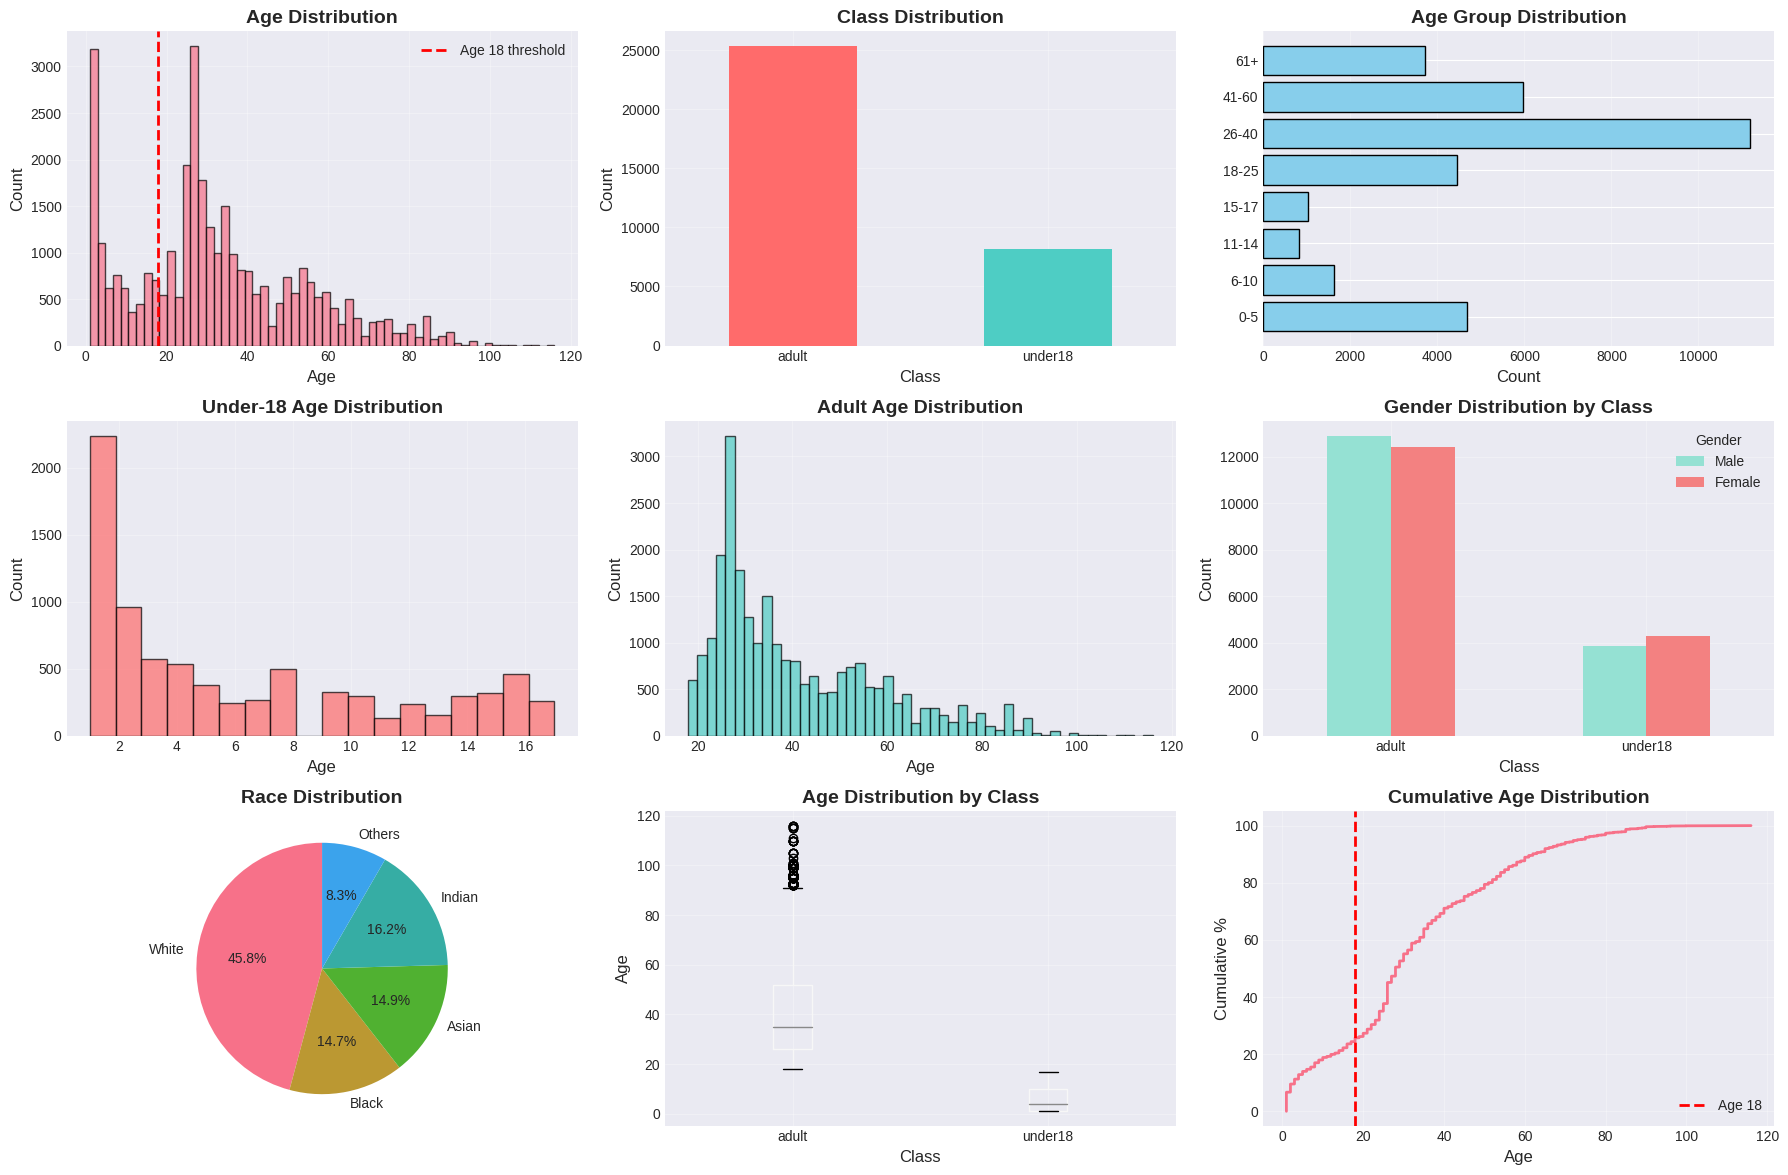

✓ Visualization saved: dataset_analysis.png


In [7]:
# Visualization
fig = plt.figure(figsize=(18, 12))

# 1. Age histogram with threshold
ax1 = plt.subplot(3, 3, 1)
plt.hist(df['age'], bins=60, edgecolor='black', alpha=0.7)
plt.axvline(x=config.AGE_THRESHOLD, color='red', linestyle='--', 
            linewidth=2, label=f'Age {config.AGE_THRESHOLD} threshold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Age Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# 2. Class distribution
ax2 = plt.subplot(3, 3, 2)
class_counts.plot(kind='bar', color=['#FF6B6B', '#4ECDC4'])
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(alpha=0.3)

# 3. Age groups
ax3 = plt.subplot(3, 3, 3)
age_group_data = []
for group_name, (min_age, max_age) in age_groups.items():
    count = len(df[(df['age'] >= min_age) & (df['age'] <= max_age)])
    age_group_data.append((group_name.split('(')[0].strip(), count))

groups, counts = zip(*age_group_data)
plt.barh(groups, counts, color='skyblue', edgecolor='black')
plt.xlabel('Count', fontsize=12)
plt.title('Age Group Distribution', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, axis='x')

# 4. Under-18 age distribution
ax4 = plt.subplot(3, 3, 4)
under18_ages = df[df['label'] == 0]['age']
plt.hist(under18_ages, bins=18, edgecolor='black', alpha=0.7, color='#FF6B6B')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Under-18 Age Distribution', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# 5. Adult age distribution
ax5 = plt.subplot(3, 3, 5)
adult_ages = df[df['label'] == 1]['age']
plt.hist(adult_ages, bins=50, edgecolor='black', alpha=0.7, color='#4ECDC4')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Adult Age Distribution', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)

# 6. Gender by class
ax6 = plt.subplot(3, 3, 6)
gender_class = pd.crosstab(df['label_name'], df['gender'])
gender_class.columns = ['Male', 'Female']
gender_class.plot(kind='bar', ax=ax6, color=['#95E1D3', '#F38181'])
plt.xlabel('Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Gender Distribution by Class', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.grid(alpha=0.3)

# 7. Race distribution
ax7 = plt.subplot(3, 3, 7)
race_names = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}
race_counts = df['race'].value_counts().sort_index()
race_labels = [race_names[i] for i in race_counts.index]
plt.pie(race_counts.values, labels=race_labels, autopct='%1.1f%%', startangle=90)
plt.title('Race Distribution', fontsize=14, fontweight='bold')

# 8. Age vs Class boxplot
ax8 = plt.subplot(3, 3, 8)
df.boxplot(column='age', by='label_name', ax=ax8)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.title('Age Distribution by Class', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove default title
plt.grid(alpha=0.3)

# 9. Cumulative age distribution
ax9 = plt.subplot(3, 3, 9)
sorted_ages = np.sort(df['age'])
cumulative = np.arange(1, len(sorted_ages) + 1) / len(sorted_ages) * 100
plt.plot(sorted_ages, cumulative, linewidth=2)
plt.axvline(x=config.AGE_THRESHOLD, color='red', linestyle='--', 
            linewidth=2, label=f'Age {config.AGE_THRESHOLD}')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Cumulative %', fontsize=12)
plt.title('Cumulative Age Distribution', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.OUTPUT_DIR, 'dataset_analysis.png'), 
            dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualization saved: dataset_analysis.png")


## Step 7: Dataset Balancing


In [8]:
# ============================================================
# STEP 7: DATASET BALANCING
# ============================================================

print("="*60)
print("DATASET BALANCING")
print("="*60)

# Separate by class
under18_df = df[df['label'] == 0].copy()
adult_df = df[df['label'] == 1].copy()

print(f"\nBefore balancing:")
print(f"  Under-18: {len(under18_df):,} samples")
print(f"  Adult: {len(adult_df):,} samples")
if len(under18_df) > 0 and len(adult_df) > 0:
    print(f"  Ratio: {len(adult_df) / len(under18_df):.2f}x imbalance")

# Determine target size (minority class size)
target_size = min(len(under18_df), len(adult_df))

print(f"\nBalancing to {target_size:,} samples per class...")

# Undersample majority class
if len(adult_df) > len(under18_df):
    adult_balanced = resample(
        adult_df,
        n_samples=target_size,
        random_state=config.RANDOM_SEED,
        replace=False
    )
    under18_balanced = under18_df.copy()
else:
    under18_balanced = resample(
        under18_df,
        n_samples=target_size,
        random_state=config.RANDOM_SEED,
        replace=False
    )
    adult_balanced = adult_df.copy()

# Combine
balanced_df = pd.concat([under18_balanced, adult_balanced], ignore_index=True)

# Shuffle
balanced_df = balanced_df.sample(frac=1, random_state=config.RANDOM_SEED).reset_index(drop=True)

print(f"\nAfter balancing:")
print(f"  Total samples: {len(balanced_df):,}")
print(balanced_df['label_name'].value_counts())

# Verify perfect balance
is_balanced = len(balanced_df[balanced_df['label']==0]) == len(balanced_df[balanced_df['label']==1])
print(f"  Perfectly balanced: {is_balanced} ✓" if is_balanced else f"  Balanced: {is_balanced} ✗")

# Save balanced dataset
balanced_df.to_csv(os.path.join(config.OUTPUT_DIR, 'balanced_dataset.csv'), index=False)
print(f"\n✓ Balanced dataset saved")
print("="*60)


DATASET BALANCING

Before balancing:
  Under-18: 8,158 samples
  Adult: 25,325 samples
  Ratio: 3.10x imbalance

Balancing to 8,158 samples per class...

After balancing:
  Total samples: 16,316
label_name
under18    8158
adult      8158
Name: count, dtype: int64
  Perfectly balanced: True ✓

✓ Balanced dataset saved


## Step 8: Train-Val-Test Split


In [9]:
# ============================================================
# STEP 8: TRAIN-VAL-TEST SPLIT
# ============================================================

print("="*60)
print("TRAIN-VAL-TEST SPLIT")
print("="*60)

# First split: train vs temp (70% vs 30%)
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=(config.VAL_RATIO + config.TEST_RATIO),
    stratify=balanced_df['label'],
    random_state=config.RANDOM_SEED
)

# Second split: val vs test (15% vs 15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=config.TEST_RATIO / (config.VAL_RATIO + config.TEST_RATIO),
    stratify=temp_df['label'],
    random_state=config.RANDOM_SEED
)

print(f"\nSplit completed:")
print(f"\nTraining set: {len(train_df):,} images ({config.TRAIN_RATIO*100:.0f}%)")
print(train_df['label_name'].value_counts())

print(f"\nValidation set: {len(val_df):,} images ({config.VAL_RATIO*100:.0f}%)")
print(val_df['label_name'].value_counts())

print(f"\nTest set: {len(test_df):,} images ({config.TEST_RATIO*100:.0f}%)")
print(test_df['label_name'].value_counts())

# Verify splits
total = len(balanced_df)
print(f"\nVerification:")
print(f"  Train %: {len(train_df)/total*100:.2f}%")
print(f"  Val %: {len(val_df)/total*100:.2f}%")
print(f"  Test %: {len(test_df)/total*100:.2f}%")
print(f"  Total check: {len(train_df) + len(val_df) + len(test_df) == total} ✓")

# Save splits
train_df.to_csv(os.path.join(config.OUTPUT_DIR, 'train_split.csv'), index=False)
val_df.to_csv(os.path.join(config.OUTPUT_DIR, 'val_split.csv'), index=False)
test_df.to_csv(os.path.join(config.OUTPUT_DIR, 'test_split.csv'), index=False)

print(f"\n✓ Split CSVs saved")
print("="*60)


TRAIN-VAL-TEST SPLIT

Split completed:

Training set: 11,421 images (70%)
label_name
adult      5711
under18    5710
Name: count, dtype: int64

Validation set: 2,447 images (15%)
label_name
under18    1224
adult      1223
Name: count, dtype: int64

Test set: 2,448 images (15%)
label_name
under18    1224
adult      1224
Name: count, dtype: int64

Verification:
  Train %: 70.00%
  Val %: 15.00%
  Test %: 15.00%
  Total check: True ✓

✓ Split CSVs saved


## Step 9: Data Transforms (584×584)


In [10]:
# ============================================================
# STEP 9: DATA TRANSFORMS (584×584 MAXIMUM SIZE)
# ============================================================

print("="*60)
print("DATA TRANSFORMS")
print("="*60)

# Training transforms with heavy augmentation for 584×584
train_transforms = transforms.Compose([
    # Resize to slightly larger for cropping
    transforms.Resize((640, 640)),
    
    # Random resized crop
    transforms.RandomResizedCrop(
        config.IMAGE_SIZE,  # 584×584
        scale=(0.85, 1.0),  # Crop 85-100%
        ratio=(0.95, 1.05)  # Near-square
    ),
    
    # Random horizontal flip
    transforms.RandomHorizontalFlip(p=0.5),
    
    # Random rotation
    transforms.RandomRotation(
        degrees=12,
        fill=0
    ),
    
    # Color augmentation
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.25,
        saturation=0.20,
        hue=0.05
    ),
    
    # Random Gaussian blur
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
    ], p=0.25),
    
    # Random grayscale
    transforms.RandomGrayscale(p=0.1),
    
    # Random perspective
    transforms.RandomPerspective(distortion_scale=0.2, p=0.2),
    
    # Convert to tensor
    transforms.ToTensor(),
    
    # Normalize with ImageNet stats
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
    
    # Random erasing (cutout)
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3),
        value='random'
    )
])

# Validation/Test transforms (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(f"✓ Training transforms defined for {config.IMAGE_SIZE}×{config.IMAGE_SIZE}")
print(f"✓ Validation transforms defined for {config.IMAGE_SIZE}×{config.IMAGE_SIZE}")
print("="*60)


DATA TRANSFORMS
✓ Training transforms defined for 584×584
✓ Validation transforms defined for 584×584


Sample image: Age 42 (adult)


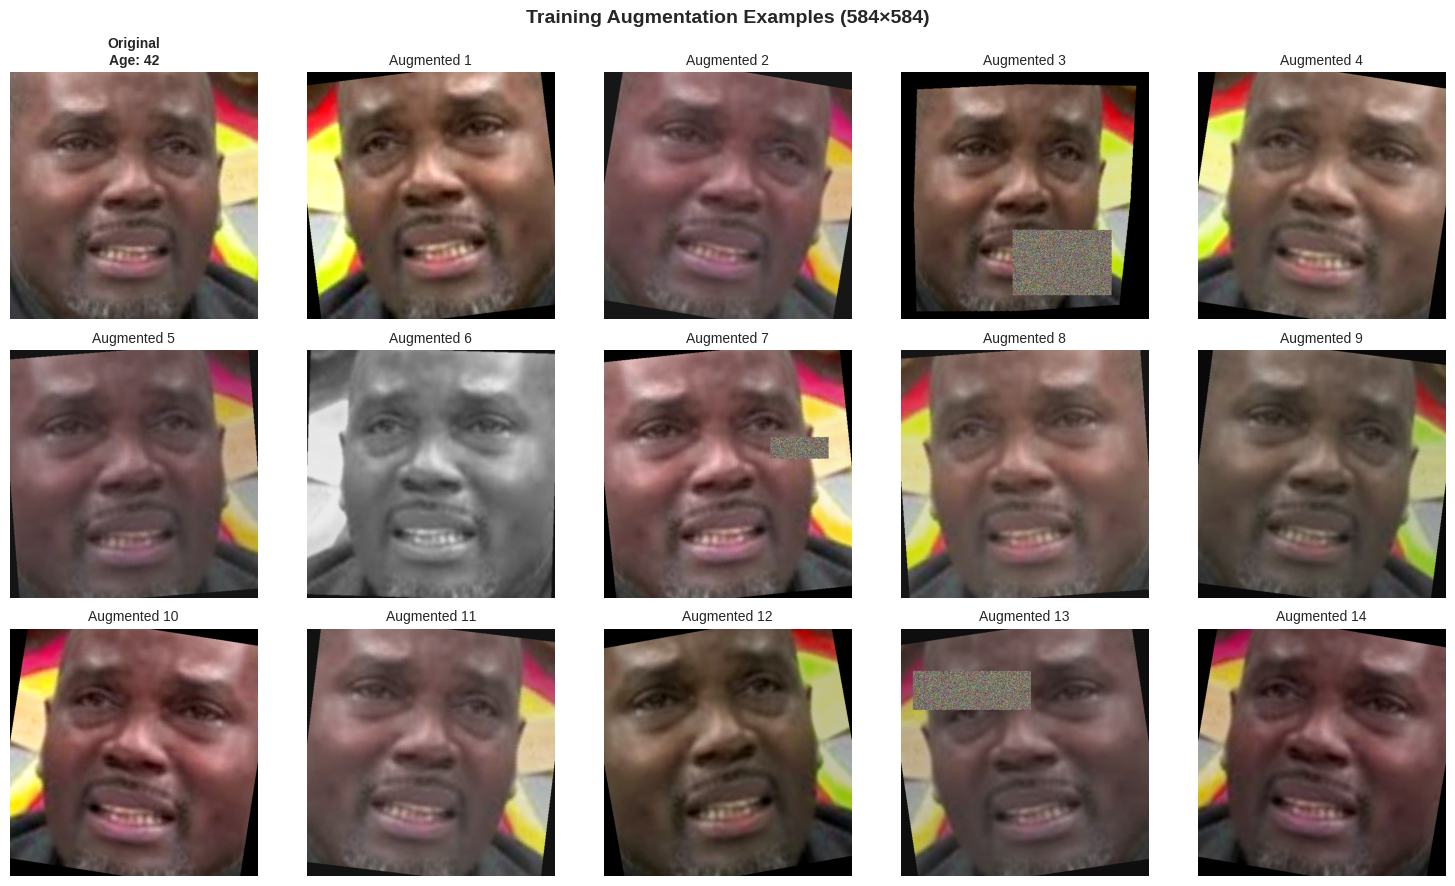

✓ Augmentation visualization saved


In [11]:
# Visualize augmentations
if len(train_df) > 0:
    sample_idx = np.random.randint(0, len(train_df))
    sample_path = train_df.iloc[sample_idx]['filepath']
    sample_age = train_df.iloc[sample_idx]['age']
    sample_label = train_df.iloc[sample_idx]['label_name']
    
    try:
        original_image = Image.open(sample_path).convert('RGB')
        
        print(f"Sample image: Age {sample_age} ({sample_label})")
        
        # Generate augmented versions
        fig, axes = plt.subplots(3, 5, figsize=(15, 9))
        axes = axes.flatten()
        
        # Original
        axes[0].imshow(original_image)
        axes[0].set_title(f'Original\nAge: {sample_age}', fontsize=10, fontweight='bold')
        axes[0].axis('off')
        
        # Augmented versions
        for i in range(1, 15):
            augmented_tensor = train_transforms(original_image)
            
            # Denormalize for visualization
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            denorm = augmented_tensor * std + mean
            denorm = torch.clamp(denorm, 0, 1)
            
            axes[i].imshow(denorm.permute(1, 2, 0))
            axes[i].set_title(f'Augmented {i}', fontsize=10)
            axes[i].axis('off')
        
        plt.suptitle(f'Training Augmentation Examples ({config.IMAGE_SIZE}×{config.IMAGE_SIZE})', 
                     fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(os.path.join(config.OUTPUT_DIR, 'augmentation_examples.png'), 
                    dpi=200, bbox_inches='tight')
        plt.show()
        
        print("✓ Augmentation visualization saved")
    except Exception as e:
        print(f"⚠ Could not visualize augmentations: {e}")


## Step 10: PyTorch Dataset Class


In [12]:
# ============================================================
# STEP 10: PYTORCH DATASET CLASS
# ============================================================

class AgeClassificationDataset(Dataset):
    """
    Custom Dataset for age-based binary classification
    """
    
    def __init__(self, dataframe, transform=None, return_metadata=False):
        """
        Args:
            dataframe: pandas DataFrame with columns ['filepath', 'label', 'age']
            transform: torchvision transforms
            return_metadata: if True, returns (image, label, metadata)
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.return_metadata = return_metadata
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        # Get row
        row = self.dataframe.iloc[idx]
        
        img_path = row['filepath']
        label = row['label']
        age = row['age']
        
        # Load image
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # Fallback for corrupted images
            if rank == 0:
                print(f"Warning: Error loading {img_path}: {e}")
            image = Image.new('RGB', (config.IMAGE_SIZE, config.IMAGE_SIZE), color=(128, 128, 128))
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        if self.return_metadata:
            metadata = {
                'filename': row['filename'],
                'age': age,
                'gender': row['gender'],
                'race': row['race']
            }
            return image, label, metadata
        else:
            return image, label

print("✓ AgeClassificationDataset class defined")


✓ AgeClassificationDataset class defined


In [13]:
# Create dataset instances
train_dataset = AgeClassificationDataset(
    train_df,
    transform=train_transforms,
    return_metadata=False
)

val_dataset = AgeClassificationDataset(
    val_df,
    transform=val_transforms,
    return_metadata=False
)

test_dataset = AgeClassificationDataset(
    test_df,
    transform=val_transforms,
    return_metadata=True  # Return metadata for analysis
)

print("="*60)
print("DATASET INSTANCES")
print("="*60)
print(f"Training dataset: {len(train_dataset):,} samples")
print(f"Validation dataset: {len(val_dataset):,} samples")
print(f"Test dataset: {len(test_dataset):,} samples")
print("="*60)

# Test loading
if rank == 0:
    print("\nTesting dataset loading...")
    sample_img, sample_label = train_dataset[0]
    print(f"✓ Training sample shape: {sample_img.shape}")
    print(f"✓ Label: {sample_label} ({config.CLASS_NAMES[sample_label]})")
    print(f"✓ Dtype: {sample_img.dtype}")
    print(f"✓ Value range: [{sample_img.min():.3f}, {sample_img.max():.3f}]")
    
    sample_img, sample_label = val_dataset[0]
    print(f"✓ Validation sample shape: {sample_img.shape}")
    
    sample_img, sample_label, metadata = test_dataset[0]
    print(f"✓ Test sample shape: {sample_img.shape}")
    print(f"✓ Metadata: {metadata}")
    print("\n✓ All datasets working correctly")


DATASET INSTANCES
Training dataset: 11,421 samples
Validation dataset: 2,447 samples
Test dataset: 2,448 samples

Testing dataset loading...
✓ Training sample shape: torch.Size([3, 584, 584])
✓ Label: 0 (under18)
✓ Dtype: torch.float32
✓ Value range: [-4.218, 4.456]
✓ Validation sample shape: torch.Size([3, 584, 584])
✓ Test sample shape: torch.Size([3, 584, 584])
✓ Metadata: {'filename': '5_1_3_20170119151512160.jpg.chip.jpg', 'age': 5, 'gender': 1, 'race': 3}

✓ All datasets working correctly


## Step 11: DataLoaders with DDP Support


In [14]:
# ============================================================
# STEP 11: DATALOADERS WITH DDP SUPPORT
# ============================================================

print("="*60)
print("CREATING DATALOADERS")
print("="*60)

# Create DistributedSampler for training if using DDP (not needed for DataParallel)
if world_size > 1 and use_ddp:
    # DDP requires DistributedSampler to split data across processes
    train_sampler = DistributedSampler(
        train_dataset,
        num_replicas=world_size,
        rank=rank,
        shuffle=True,
        seed=config.RANDOM_SEED
    )
    val_sampler = DistributedSampler(
        val_dataset,
        num_replicas=world_size,
        rank=rank,
        shuffle=False
    )
    shuffle_train = False  # Sampler handles shuffling
else:
    # DataParallel or single GPU - no sampler needed
    train_sampler = None
    val_sampler = None
    shuffle_train = True

# Training DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=shuffle_train,
    sampler=train_sampler,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY,
    drop_last=True  # Drop last incomplete batch for stable training
)

# Validation DataLoader
val_loader = DataLoader(
    val_dataset,
    batch_size=config.BATCH_SIZE * 2,  # Larger batch (no gradients)
    shuffle=False,
    sampler=val_sampler,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY,
    drop_last=False
)

# Test DataLoader (no sampler needed, only rank 0 evaluates)
test_loader = DataLoader(
    test_dataset,
    batch_size=config.BATCH_SIZE * 2,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=config.PIN_MEMORY,
    drop_last=False
)

if rank == 0:
    print(f"✓ Training batches: {len(train_loader)}")
    print(f"✓ Validation batches: {len(val_loader)}")
    print(f"✓ Test batches: {len(test_loader)}")
    print(f"\nEstimated iterations per epoch: {len(train_loader)}")
    print(f"Total training iterations ({config.NUM_EPOCHS} epochs): {len(train_loader) * config.NUM_EPOCHS:,}")
    training_mode = 'DDP' if (world_size > 1 and use_ddp) else ('DataParallel' if world_size > 1 else 'Single GPU')
    print(f"Training mode: {training_mode}")
print("="*60)


CREATING DATALOADERS
✓ Training batches: 356
✓ Validation batches: 39
✓ Test batches: 39

Estimated iterations per epoch: 356
Total training iterations (60 epochs): 21,360
Training mode: DataParallel


In [15]:
# Test DataLoader
if rank == 0:
    print("\nTesting DataLoader...")
    
    # Get a batch
    sample_batch = next(iter(train_loader))
    images, labels = sample_batch
    
    print(f"✓ Batch images shape: {images.shape}")
    print(f"✓ Batch labels shape: {labels.shape}")
    print(f"✓ Batch memory: {images.element_size() * images.nelement() / 1e6:.2f} MB")
    print(f"✓ Labels in batch: {labels.tolist()[:10]}")
    print(f"✓ Class distribution: under18={((labels==0).sum().item())}, adult={((labels==1).sum().item())}")
    
    print("\n✓ DataLoaders working correctly")



Testing DataLoader...
✓ Batch images shape: torch.Size([32, 3, 584, 584])
✓ Batch labels shape: torch.Size([32])
✓ Batch memory: 130.97 MB
✓ Labels in batch: [0, 0, 0, 0, 1, 0, 1, 1, 1, 1]
✓ Class distribution: under18=15, adult=17

✓ DataLoaders working correctly


## Step 12: Model Definition with DDP


In [16]:
# ============================================================
# STEP 12: MODEL DEFINITION WITH DDP
# ============================================================

print("="*60)
print("MODEL DEFINITION")
print("="*60)

# Load pre-trained EfficientNet-B3
if rank == 0:
    print(f"Loading {config.MODEL_NAME} (pre-trained: {config.PRETRAINED})...")

if config.PRETRAINED:
    weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
    model = models.efficientnet_b3(weights=weights)
else:
    model = models.efficientnet_b3(weights=None)

if rank == 0:
    print(f"✓ {config.MODEL_NAME} loaded")

# Get number of input features to classifier
num_features = model.classifier[1].in_features

if rank == 0:
    print(f"Original classifier input features: {num_features}")

# Replace classifier
# Note: inplace=False is required for mixed precision training (AMP) with DataParallel/DDP
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=False),
    nn.Linear(num_features, 512),
    nn.ReLU(inplace=False),  # inplace=False prevents gradient computation errors with AMP
    nn.Dropout(p=0.2, inplace=False),
    nn.Linear(512, config.NUM_CLASSES)
)

if rank == 0:
    print(f"✓ Classifier replaced: {num_features} → 512 → {config.NUM_CLASSES}")

# Move model to device
model = model.to(device)

# Use DDP or DataParallel for multi-GPU
if world_size > 1:
    if use_ddp:
        # Proper DDP (requires environment variables)
        model = DDP(model, device_ids=[local_rank], output_device=local_rank, find_unused_parameters=False)
        if rank == 0:
            print(f"\n✓ Using DDP with {world_size} GPUs")
    else:
        # DataParallel (notebook-friendly, works without env vars)
        model = nn.DataParallel(model)
        if rank == 0:
            print(f"\n✓ Using DataParallel with {world_size} GPUs (notebook mode)")
else:
    if rank == 0:
        print(f"\n✓ Using single GPU: {device}")

# Count parameters
def count_parameters(model):
    """Count model parameters"""
    # Unwrap DDP or DataParallel
    if isinstance(model, (DDP, nn.DataParallel)):
        model = model.module
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(model)

if rank == 0:
    print(f"\nModel parameters:")
    print(f"  Total: {total_params:,}")
    print(f"  Trainable: {trainable_params:,}")
    print(f"  Non-trainable: {total_params - trainable_params:,}")
    print(f"  Model size: ~{total_params * 4 / 1e6:.1f} MB (FP32)")
    print("="*60)


MODEL DEFINITION
Loading efficientnet_b3 (pre-trained: True)...


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████| 47.2M/47.2M [00:00<00:00, 186MB/s]


✓ efficientnet_b3 loaded
Original classifier input features: 1536
✓ Classifier replaced: 1536 → 512 → 2

✓ Using DataParallel with 2 GPUs (notebook mode)

Model parameters:
  Total: 11,484,202
  Trainable: 11,484,202
  Non-trainable: 0
  Model size: ~45.9 MB (FP32)


## Step 13: Loss Function & Optimizer


In [17]:
# ============================================================
# STEP 13: LOSS FUNCTION & OPTIMIZER
# ============================================================

print("="*60)
print("LOSS FUNCTION & OPTIMIZER")
print("="*60)

# Get model parameters (unwrap DDP or DataParallel if needed)
if isinstance(model, (DDP, nn.DataParallel)):
    model_params = model.module.parameters()
else:
    model_params = model.parameters()

# Class weights (prioritize under-18 recall)
class_weights = torch.tensor([1.5, 1.0]).to(device)  # [under18, adult]

# Loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = optim.AdamW(
    model_params,
    lr=config.LEARNING_RATE,
    weight_decay=config.WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',  # Maximize val recall
    factor=config.SCHEDULER_FACTOR,
    patience=config.SCHEDULER_PATIENCE,
    verbose=(rank == 0),  # Only print on rank 0
    min_lr=config.SCHEDULER_MIN_LR
)

# Mixed precision scaler
if config.USE_AMP:
    scaler = torch.cuda.amp.GradScaler()
    if rank == 0:
        print("✓ Mixed Precision (FP16) enabled")
else:
    scaler = None
    if rank == 0:
        print("✓ Using FP32 training")

if rank == 0:
    print(f"✓ Loss function: Weighted CrossEntropyLoss")
    print(f"  Class weights: under18={class_weights[0].item()}, adult={class_weights[1].item()}")
    print(f"✓ Optimizer: AdamW")
    print(f"  Base Learning Rate: {config.BASE_LEARNING_RATE}")
    print(f"  Scaled Learning Rate: {config.LEARNING_RATE} (×{world_size} for {world_size} GPU{'s' if world_size > 1 else ''})")
    print(f"  Effective Batch Size: {config.BATCH_SIZE * world_size}")
    print(f"  LR per Sample: {config.LEARNING_RATE / (config.BATCH_SIZE * world_size):.2e}")
    print(f"  Weight decay: {config.WEIGHT_DECAY}")
    print(f"✓ Scheduler: ReduceLROnPlateau")
    print(f"  Mode: maximize val_under18_recall")
    print(f"  Patience: {config.SCHEDULER_PATIENCE} epochs")
    print(f"  Factor: {config.SCHEDULER_FACTOR}")
    print(f"  Min LR: {config.SCHEDULER_MIN_LR}")
    if world_size > 1:
        print(f"\n  LR Scaling Rationale:")
        print(f"     - With {world_size} GPUs, effective batch size = {config.BATCH_SIZE * world_size}")
        print(f"     - Linear scaling: LR = base_lr × num_gpus = {config.BASE_LEARNING_RATE} × {world_size} = {config.LEARNING_RATE}")
        print(f"     - This maintains same learning rate per sample across different batch sizes")
print("="*60)


LOSS FUNCTION & OPTIMIZER
✓ Mixed Precision (FP16) enabled
✓ Loss function: Weighted CrossEntropyLoss
  Class weights: under18=1.5, adult=1.0
✓ Optimizer: AdamW
  Base Learning Rate: 0.001
  Scaled Learning Rate: 0.002 (×2 for 2 GPUs)
  Effective Batch Size: 64
  LR per Sample: 3.13e-05
  Weight decay: 0.0001
✓ Scheduler: ReduceLROnPlateau
  Mode: maximize val_under18_recall
  Patience: 5 epochs
  Factor: 0.5
  Min LR: 1e-06

  📊 LR Scaling Rationale:
     - With 2 GPUs, effective batch size = 64
     - Linear scaling: LR = base_lr × num_gpus = 0.001 × 2 = 0.002
     - This maintains same learning rate per sample across different batch sizes


In [18]:
# ============================================================
# STEP 14: TRAINING UTILITIES
# ============================================================

def calculate_metrics(y_true, y_pred):
    """Calculate classification metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    
    # Per-class metrics
    precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    # Overall metrics
    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    return {
        'accuracy': accuracy,
        'under18_precision': precision_per_class[0],
        'under18_recall': recall_per_class[0],
        'under18_f1': f1_per_class[0],
        'adult_precision': precision_per_class[1],
        'adult_recall': recall_per_class[1],
        'adult_f1': f1_per_class[1],
        'macro_precision': precision_macro,
        'macro_recall': recall_macro,
        'macro_f1': f1_macro
    }

def print_metrics(metrics, prefix=""):
    """Pretty print metrics"""
    print(f"\n{prefix}Metrics:")
    print(f"  Accuracy: {metrics['accuracy']*100:.2f}%")
    print(f"  Under-18: Precision={metrics['under18_precision']*100:.2f}%, "
          f"Recall={metrics['under18_recall']*100:.2f}%, F1={metrics['under18_f1']:.4f}")
    print(f"  Adult: Precision={metrics['adult_precision']*100:.2f}%, "
          f"Recall={metrics['adult_recall']*100:.2f}%, F1={metrics['adult_f1']:.4f}")

if rank == 0:
    print("✓ Utility functions defined")


✓ Utility functions defined


## Step 15: Training Loop with DDP


In [19]:
# ============================================================
# STEP 15: TRAINING LOOP WITH DDP
# ============================================================

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_under18_recall': [],
    'val_adult_recall': [],
    'learning_rate': []
}

# Best model tracking
best_val_recall = 0.0
best_epoch = 0
patience_counter = 0

# Checkpoint directory
checkpoint_dir = os.path.join(config.OUTPUT_DIR, 'checkpoints')
os.makedirs(checkpoint_dir, exist_ok=True)

if rank == 0:
    print("="*60)
    print("STARTING TRAINING")
    print("="*60)
    print(f"Total epochs: {config.NUM_EPOCHS}")
    print(f"Early stopping patience: {config.EARLY_STOPPING_PATIENCE}")
    print(f"Monitoring metric: {config.METRIC_TO_MONITOR}")
    print("="*60)

# Training loop
for epoch in range(config.NUM_EPOCHS):
    epoch_start_time = time.time()
    
    # Set epoch for DistributedSampler (only needed for DDP)
    if world_size > 1 and use_ddp and train_sampler is not None:
        train_sampler.set_epoch(epoch)
    
    # ========== TRAINING PHASE ==========
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    all_train_preds = []
    all_train_labels = []
    
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{config.NUM_EPOCHS} [Train]', 
                      disable=(rank != 0))
    
    for batch_idx, (images, labels) in enumerate(train_pbar):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass with mixed precision
        if config.USE_AMP:
            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            # Backward pass
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        # Statistics
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        # Collect predictions for metrics
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())
        
        # Update progress bar
        if rank == 0:
            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100*train_correct/train_total:.2f}%'
            })
    
    # Average training loss
    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    
    # ========== VALIDATION PHASE ==========
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    all_val_preds = []
    all_val_labels = []
    
    val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{config.NUM_EPOCHS} [Val]', 
                    disable=(rank != 0))
    
    with torch.no_grad():
        for images, labels in val_pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # Forward pass
            if config.USE_AMP:
                with torch.cuda.amp.autocast():
                    outputs = model(images)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            # Statistics
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            # Collect predictions
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
            
            if rank == 0:
                val_pbar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{100*val_correct/val_total:.2f}%'
                })
    
    # Average validation loss
    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    
    # Calculate detailed metrics (only on rank 0)
    if rank == 0:
        val_metrics = calculate_metrics(all_val_labels, all_val_preds)
        val_under18_recall = val_metrics['under18_recall']
        
        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_under18_recall'].append(val_under18_recall)
        history['val_adult_recall'].append(val_metrics['adult_recall'])
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])
        
        # Learning rate scheduling
        scheduler.step(val_under18_recall)
        
        # Checkpoint saving
        is_best = val_under18_recall > best_val_recall
        if is_best:
            best_val_recall = val_under18_recall
            best_epoch = epoch + 1
            patience_counter = 0
            
            # Save best model (unwrap DDP or DataParallel if needed)
            if isinstance(model, (DDP, nn.DataParallel)):
                model_state = model.module.state_dict()
            else:
                model_state = model.state_dict()
            
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model_state,
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_recall': best_val_recall,
                'val_metrics': val_metrics,
                'config': config.__dict__
            }
            
            torch.save(checkpoint, os.path.join(checkpoint_dir, 'best_model.pth'))
            print(f"\n✓ Best model saved! Val Under-18 Recall: {best_val_recall*100:.2f}%")
        else:
            patience_counter += 1
        
        # Epoch summary
        epoch_time = time.time() - epoch_start_time
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{config.NUM_EPOCHS} Summary")
        print(f"{'='*60}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
        print_metrics(val_metrics, prefix="Val ")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        print(f"Time: {epoch_time:.2f}s")
        print(f"Best Epoch: {best_epoch} (Recall: {best_val_recall*100:.2f}%)")
        print(f"Early Stopping: {patience_counter}/{config.EARLY_STOPPING_PATIENCE}")
        print(f"{'='*60}\n")
        
        # Early stopping
        if patience_counter >= config.EARLY_STOPPING_PATIENCE:
            print(f"\n⚠ Early stopping triggered! No improvement for {config.EARLY_STOPPING_PATIENCE} epochs.")
            print(f"Best model was at epoch {best_epoch} with Val Under-18 Recall: {best_val_recall*100:.2f}%")
            break
    
    # Synchronize all processes (only needed for DDP)
    if world_size > 1 and use_ddp:
        dist.barrier()

if rank == 0:
    print("\n" + "="*60)
    print("TRAINING COMPLETED")
    print("="*60)
    print(f"Best epoch: {best_epoch}")
    print(f"Best Val Under-18 Recall: {best_val_recall*100:.2f}%")
    print("="*60)


STARTING TRAINING
Total epochs: 60
Early stopping patience: 12
Monitoring metric: val_under18_recall


Epoch 1/60 [Train]:   0%|          | 0/356 [00:00<?, ?it/s]

Epoch 1/60 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]


✓ Best model saved! Val Under-18 Recall: 89.87%

Epoch 1/60 Summary
Train Loss: 0.3366 | Train Acc: 85.31%
Val Loss: 0.2197 | Val Acc: 92.24%

Val Metrics:
  Accuracy: 92.24%
  Under-18: Precision=94.34%, Recall=89.87%, F1=0.9205
  Adult: Precision=90.32%, Recall=94.60%, F1=0.9241
Learning Rate: 0.002000
Time: 374.36s
Best Epoch: 1 (Recall: 89.87%)
Early Stopping: 0/12



Epoch 2/60 [Train]:   0%|          | 0/356 [00:00<?, ?it/s]

...

Epoch 16/60 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]


Epoch 16/60 Summary
Train Loss: 0.0619 | Train Acc: 97.77%
Val Loss: 0.1155 | Val Acc: 96.98%

Val Metrics:
  Accuracy: 96.98%
  Under-18: Precision=98.32%, Recall=95.59%, F1=0.9693
  Adult: Precision=95.70%, Recall=98.36%, F1=0.9702
Learning Rate: 0.001000
Time: 368.43s
Best Epoch: 5 (Recall: 97.55%)
Early Stopping: 11/12



Epoch 17/60 [Train]:   0%|          | 0/356 [00:00<?, ?it/s]

Epoch 17/60 [Val]:   0%|          | 0/39 [00:00<?, ?it/s]


Epoch 17/60 Summary
Train Loss: 0.0659 | Train Acc: 97.38%
Val Loss: 0.0927 | Val Acc: 96.73%

Val Metrics:
  Accuracy: 96.73%
  Under-18: Precision=96.81%, Recall=96.65%, F1=0.9673
  Adult: Precision=96.65%, Recall=96.81%, F1=0.9673
Learning Rate: 0.000500
Time: 365.64s
Best Epoch: 5 (Recall: 97.55%)
Early Stopping: 12/12


⚠ Early stopping triggered! No improvement for 12 epochs.
Best model was at epoch 5 with Val Under-18 Recall: 97.55%

TRAINING COMPLETED
Best epoch: 5
Best Val Under-18 Recall: 97.55%


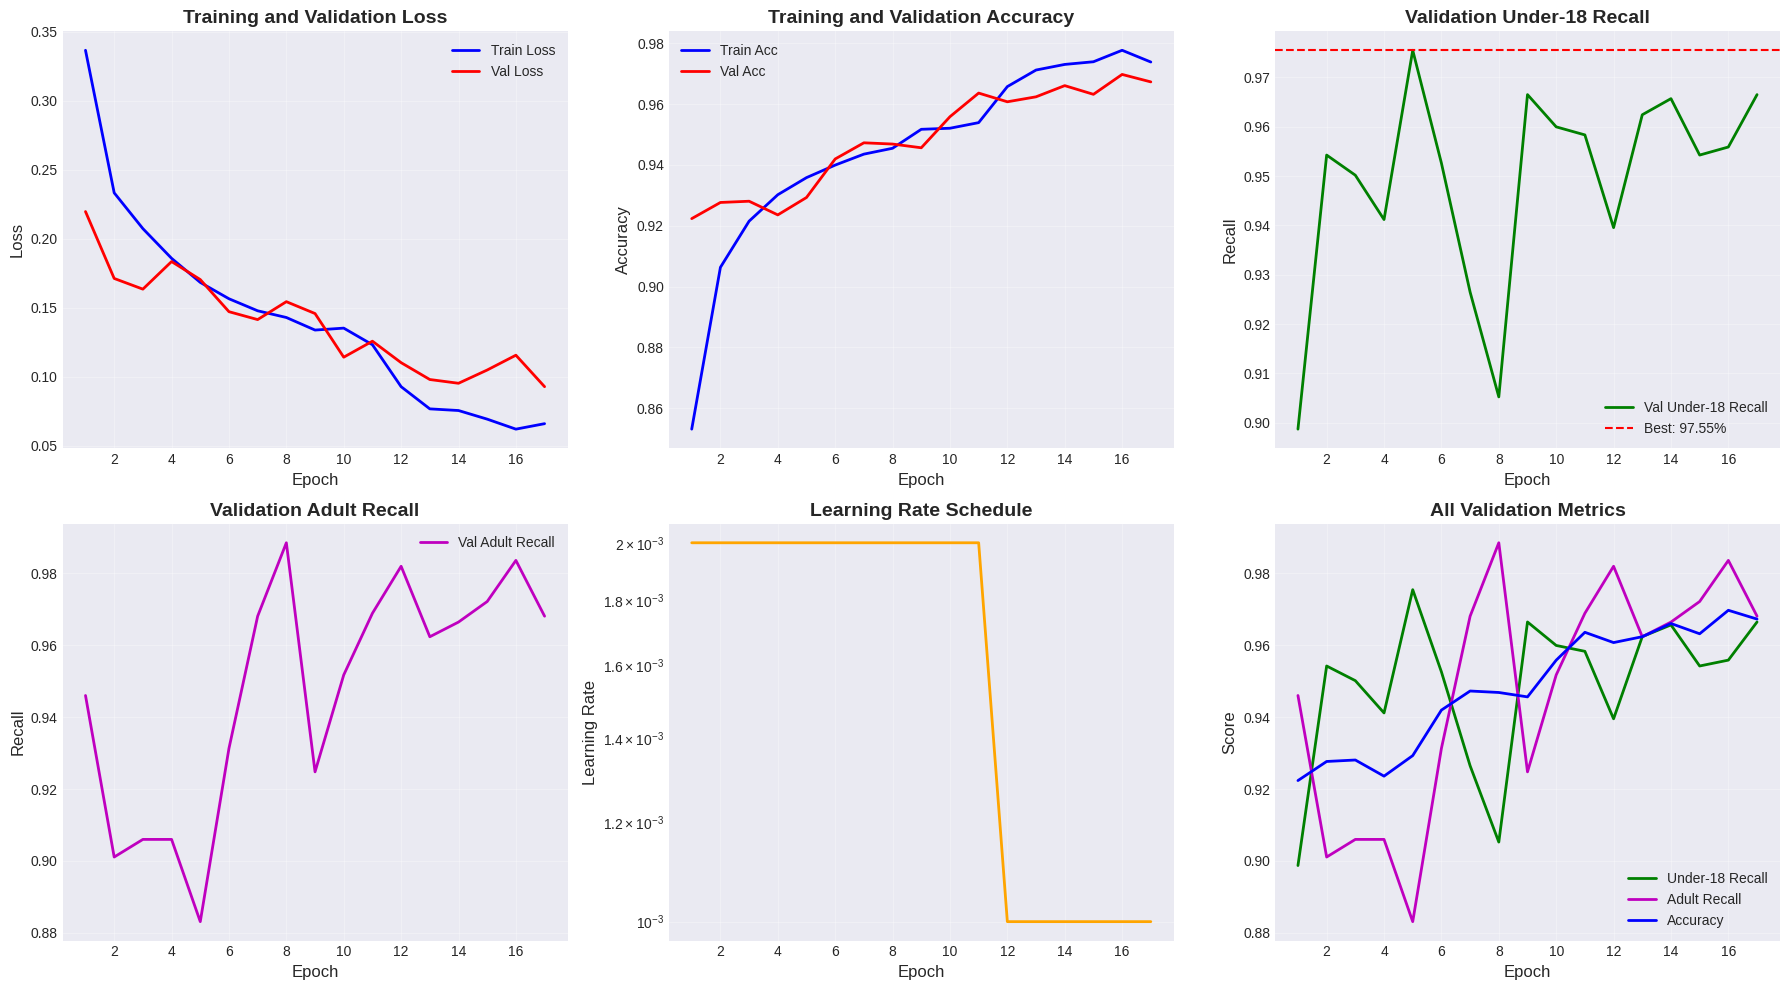

✓ Training history visualization saved


In [20]:
# ============================================================
# STEP 16: TRAINING HISTORY VISUALIZATION
# ============================================================

if rank == 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss', fontsize=12)
    axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[0, 1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Accuracy', fontsize=12)
    axes[0, 1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)
    
    # Under-18 Recall
    axes[0, 2].plot(epochs, history['val_under18_recall'], 'g-', label='Val Under-18 Recall', linewidth=2)
    axes[0, 2].axhline(y=best_val_recall, color='r', linestyle='--', label=f'Best: {best_val_recall*100:.2f}%')
    axes[0, 2].set_xlabel('Epoch', fontsize=12)
    axes[0, 2].set_ylabel('Recall', fontsize=12)
    axes[0, 2].set_title('Validation Under-18 Recall', fontsize=14, fontweight='bold')
    axes[0, 2].legend()
    axes[0, 2].grid(alpha=0.3)
    
    # Adult Recall
    axes[1, 0].plot(epochs, history['val_adult_recall'], 'm-', label='Val Adult Recall', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Recall', fontsize=12)
    axes[1, 0].set_title('Validation Adult Recall', fontsize=14, fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)
    
    # Learning Rate
    axes[1, 1].plot(epochs, history['learning_rate'], 'orange', linewidth=2)
    axes[1, 1].set_xlabel('Epoch', fontsize=12)
    axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
    axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(alpha=0.3)
    
    # Combined metrics
    axes[1, 2].plot(epochs, history['val_under18_recall'], 'g-', label='Under-18 Recall', linewidth=2)
    axes[1, 2].plot(epochs, history['val_adult_recall'], 'm-', label='Adult Recall', linewidth=2)
    axes[1, 2].plot(epochs, history['val_acc'], 'b-', label='Accuracy', linewidth=2)
    axes[1, 2].set_xlabel('Epoch', fontsize=12)
    axes[1, 2].set_ylabel('Score', fontsize=12)
    axes[1, 2].set_title('All Validation Metrics', fontsize=14, fontweight='bold')
    axes[1, 2].legend()
    axes[1, 2].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(config.OUTPUT_DIR, 'training_history.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Training history visualization saved")


## Step 17: Load Best Model & Test Evaluation


LOADING BEST MODEL
✓ Best model loaded from epoch 5
✓ Best Val Under-18 Recall: 97.55%

TEST SET EVALUATION


Testing:   0%|          | 0/39 [00:00<?, ?it/s]


TEST SET RESULTS

Test Metrics:
  Accuracy: 93.34%
  Under-18: Precision=90.34%, Recall=97.06%, F1=0.9358
  Adult: Precision=96.82%, Recall=89.62%, F1=0.9308


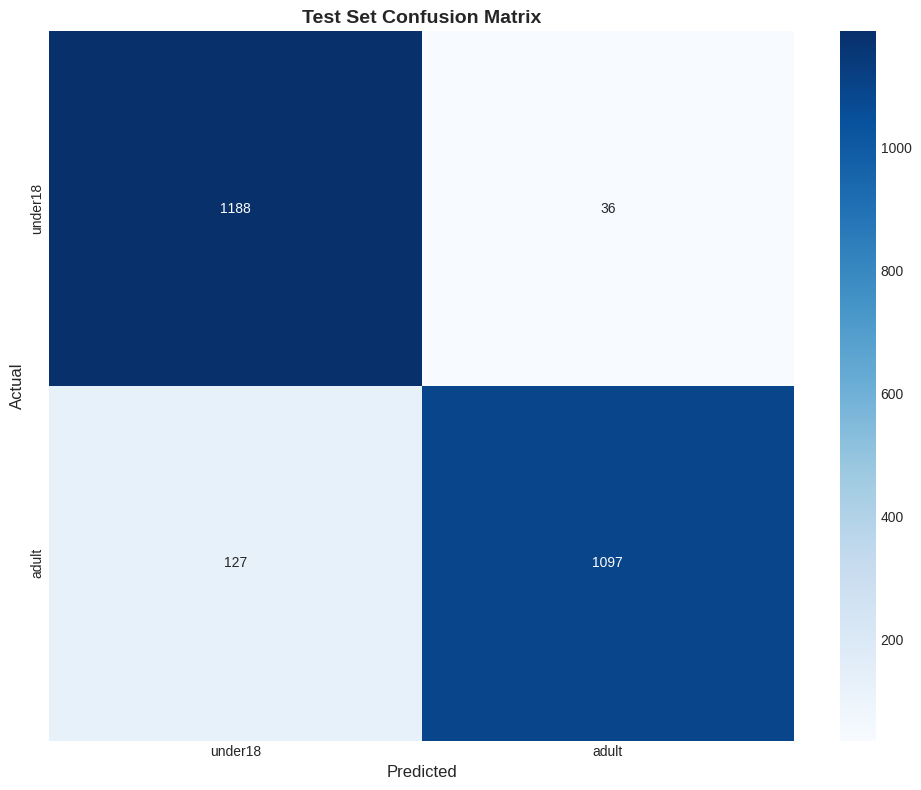

✓ Confusion matrix saved

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     under18     0.9034    0.9706    0.9358      1224
       adult     0.9682    0.8962    0.9308      1224

    accuracy                         0.9334      2448
   macro avg     0.9358    0.9334    0.9333      2448
weighted avg     0.9358    0.9334    0.9333      2448



In [21]:
# ============================================================
# STEP 17: LOAD BEST MODEL & TEST EVALUATION
# ============================================================

if rank == 0:
    print("="*60)
    print("LOADING BEST MODEL")
    print("="*60)

    # Load best checkpoint
    checkpoint_path = os.path.join(checkpoint_dir, 'best_model.pth')

    # For PyTorch >= 2.6, default weights_only=True can break older checkpoints.
    # We explicitly set weights_only=False here because this checkpoint was
    # created by our own training code and is trusted.
    try:
        checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=False  # <-- important change
        )
    except TypeError:
        # For older PyTorch versions that don't support weights_only argument
        checkpoint = torch.load(checkpoint_path, map_location=device)

    # Load model state (unwrap DDP or DataParallel if needed)
    if isinstance(model, (DDP, nn.DataParallel)):
        model.module.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint['model_state_dict'])

    print(f"✓ Best model loaded from epoch {checkpoint['epoch']}")
    print(f"✓ Best Val Under-18 Recall: {checkpoint['best_val_recall']*100:.2f}%")

    # Test evaluation
    print("\n" + "="*60)
    print("TEST SET EVALUATION")
    print("="*60)

    model.eval()
    all_test_preds = []
    all_test_labels = []
    all_test_metadata = []

    test_pbar = tqdm(test_loader, desc='Testing')

    with torch.no_grad():
        for images, labels, metadata in test_pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if config.USE_AMP:
                with torch.cuda.amp.autocast():
                    outputs = model(images)
            else:
                outputs = model(images)

            _, predicted = torch.max(outputs.data, 1)

            all_test_preds.extend(predicted.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())
            all_test_metadata.extend(metadata)

    # Calculate test metrics
    test_metrics = calculate_metrics(all_test_labels, all_test_preds)

    print("\n" + "="*60)
    print("TEST SET RESULTS")
    print("="*60)
    print_metrics(test_metrics, prefix="Test ")
    print("="*60)

    # Confusion Matrix
    cm = confusion_matrix(all_test_labels, all_test_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=config.CLASS_NAMES,
                yticklabels=config.CLASS_NAMES)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title('Test Set Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(config.OUTPUT_DIR, 'test_confusion_matrix.png'),
                dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Confusion matrix saved")

    # Classification Report
    print("\n" + "="*60)
    print("DETAILED CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(all_test_labels, all_test_preds,
                                target_names=config.CLASS_NAMES, digits=4))
    print("="*60)


## Step 18: Cleanup DDP (if used)


In [22]:
# ============================================================
# STEP 18: CLEANUP DDP
# ============================================================

# Cleanup DDP process group (only if DDP was used)
if world_size > 1 and use_ddp:
    dist.destroy_process_group()
    if rank == 0:
        print("✓ DDP process group destroyed")

if rank == 0:
    print("\n" + "="*60)
    print("PIPELINE COMPLETE!")
    print("="*60)
    print(f"✓ Best model saved: {checkpoint_dir}/best_model.pth")
    print(f"✓ Training history: training_history.png")
    print(f"✓ Test results: test_confusion_matrix.png")
    print("="*60)



PIPELINE COMPLETE!
✓ Best model saved: /kaggle/working/checkpoints/best_model.pth
✓ Training history: training_history.png
✓ Test results: test_confusion_matrix.png


In [23]:
# ============================================================
# SAVE FINAL MODEL (WEIGHTS + FULL CHECKPOINT)
# ============================================================

import os
import torch
import torch.nn as nn

print("\nSaving final model snapshots...")

# Ensure output directory exists
save_dir = os.path.join(config.OUTPUT_DIR, "final_export")
os.makedirs(save_dir, exist_ok=True)

# 1) UNWRAP DDP or DataParallel
if isinstance(model, (nn.DataParallel, torch.nn.parallel.DistributedDataParallel)):
    model_to_save = model.module
else:
    model_to_save = model

# -------------------------------
# 2) SAVE WEIGHTS ONLY (.pt file)
# -------------------------------
weights_path = os.path.join(save_dir, "best_model.pt")
torch.save(model_to_save.state_dict(), weights_path)
print(f"✓ Weights-only model saved at: {weights_path}")

# -------------------------------------------
# 3) SAVE FULL CHECKPOINT (.pth file)
# -------------------------------------------
checkpoint = {
    "model_state_dict": model_to_save.state_dict(),
    "config": config.__dict__,
}

checkpoint_path = os.path.join(save_dir, "best_model.pth")
torch.save(checkpoint, checkpoint_path)
print(f"✓ Full checkpoint saved at: {checkpoint_path}")

print("\n🎉 Model export complete! You can now download or upload this folder.")



Saving final model snapshots...
✓ Weights-only model saved at: /kaggle/working/final_export/best_model.pt
✓ Full checkpoint saved at: /kaggle/working/final_export/best_model.pth

🎉 Model export complete! You can now download or upload this folder.


In [25]:
# ============================================================
# INFERENCE BLOCK (MODEL LOADING + RANDOM PREDICTIONS)
# ============================================================

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("="*60)
print("INFERENCE: LOADING TRAINED MODEL")
print("="*60)

# ---------------------------
# 1. DEVICE
# ---------------------------
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------
# 2. REBUILD MODEL EXACTLY AS TRAINING
#    (EfficientNet-B3 with head: 1536 -> 512 -> 2)
# ---------------------------
def build_efficientnet_b3_with_custom_head(num_classes=2):
    """
    EfficientNet-B3 with the same classifier structure used in training:
    classifier = [Dropout, Linear(1536->512), ReLU, Dropout, Linear(512->num_classes)]
    """
    model = models.efficientnet_b3(weights=None)
    in_features = model.classifier[1].in_features  # 1536 for B3
    
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(512, num_classes)
    )
    return model

model = build_efficientnet_b3_with_custom_head(num_classes=config.NUM_CLASSES)
model.to(device)

# ---------------------------
# 3. LOAD WEIGHTS (PT OR PTH)
# ---------------------------
pt_path  = os.path.join(config.OUTPUT_DIR, "final_export", "best_model.pt")
pth_path = os.path.join(config.OUTPUT_DIR, "checkpoints", "best_model.pth")

state_dict = None

if os.path.exists(pt_path):
    print(f"✓ Loading weights-only file: {pt_path}")
    try:
        state_dict = torch.load(pt_path, map_location=device, weights_only=False)
    except TypeError:
        state_dict = torch.load(pt_path, map_location=device)
elif os.path.exists(pth_path):
    print(f"✓ Loading full checkpoint: {pth_path}")
    try:
        checkpoint = torch.load(pth_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(pth_path, map_location=device)
    state_dict = checkpoint["model_state_dict"]
else:
    raise FileNotFoundError(
        "❌ No saved model found.\n"
        f"Tried:\n  {pt_path}\n  {pth_path}"
    )

missing, unexpected = model.load_state_dict(state_dict, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

model.eval()
print("✓ Model loaded and set to eval()")
print("="*60)

# ---------------------------
# 4. TRANSFORMS (same size as training)
# ---------------------------
transform = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    ),
])

# ---------------------------
# 5. SINGLE IMAGE PREDICTION
# ---------------------------
def predict_image(image_path, show=False):
    """
    Predict under18/adult for a single image.
    """
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))
        pred_name = config.CLASS_NAMES[pred_idx]

    print("\n" + "="*60)
    print(f"Image: {os.path.basename(image_path)}")
    print(f"Prediction: {pred_name.upper()}")
    print(f"Prob under18: {probs[0]:.4f}")
    print(f"Prob adult:   {probs[1]:.4f}")
    print("="*60)

    if show:
        plt.imshow(img)
        plt.title(f"Pred: {pred_name} | u18={probs[0]:.2f}, adult={probs[1]:.2f}")
        plt.axis("off")
        plt.show()

    return pred_idx, pred_name, probs

# ---------------------------
# 6. MULTIPLE IMAGES PREDICTION
# ---------------------------
def predict_many(image_paths, show=False):
    """
    Predict for a list of image paths.
    Returns a pandas DataFrame with predictions.
    """
    results = []
    for path in image_paths:
        pred_idx, pred_name, probs = predict_image(path, show=show)
        results.append({
            "image": os.path.basename(path),
            "path": path,
            "predicted_class": pred_name,
            "prob_under18": probs[0],
            "prob_adult": probs[1]
        })
    df_results = pd.DataFrame(results)
    return df_results

# ---------------------------
# 7. AUTO-RANDOM INFERENCE FROM df (MODEL CHOOSES IMAGES)
# ---------------------------
def infer_auto(n_samples=10, show=False):
    """
    Model randomly chooses n_samples images from df (your UTKFace dataframe)
    and runs inference on them.
    """
    if "df" not in globals():
        print("❌ DataFrame 'df' not found. Make sure dataset was loaded (STEP 5).")
        return None

    n_samples = min(n_samples, len(df))
    sampled = df.sample(n=n_samples, random_state=np.random.randint(1, 1_000_000))
    paths = sampled["filepath"].tolist()

    print(f"\n🔥 MODEL CHOSE {len(paths)} RANDOM IMAGES FROM DATASET 🔥\n")
    df_pred = predict_many(paths, show=show)
    return df_pred

print("✓ Inference helpers ready: predict_image, predict_many, infer_auto")
print("="*60)


INFERENCE: LOADING TRAINED MODEL
Using device: cuda:0
✓ Loading weights-only file: /kaggle/working/final_export/best_model.pt
Missing keys: []
Unexpected keys: []
✓ Model loaded and set to eval()
✓ Inference helpers ready: predict_image, predict_many, infer_auto



🔥 MODEL CHOSE 10 RANDOM IMAGES FROM DATASET 🔥


Image: 18_1_1_20170117140201823.jpg.chip.jpg
Prediction: ADULT
Prob under18: 0.2555
Prob adult:   0.7445


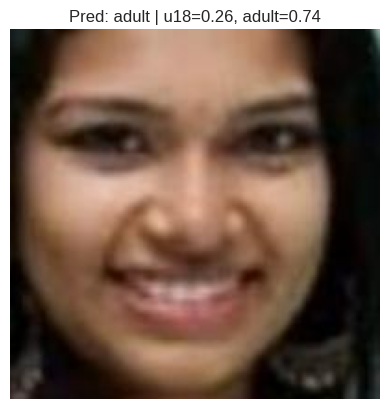


Image: 43_0_0_20170104172942851.jpg.chip.jpg
Prediction: ADULT
Prob under18: 0.0169
Prob adult:   0.9831


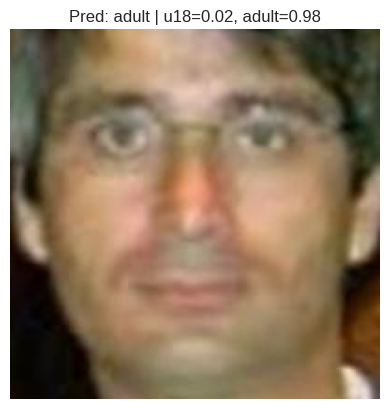


Image: 10_0_0_20170110225414790.jpg.chip.jpg
Prediction: UNDER18
Prob under18: 1.0000
Prob adult:   0.0000


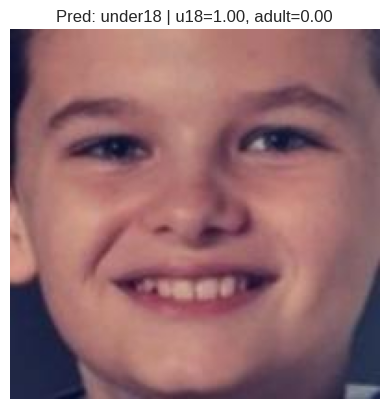


Image: 63_0_0_20170117194914689.jpg.chip.jpg
Prediction: ADULT
Prob under18: 0.0073
Prob adult:   0.9927


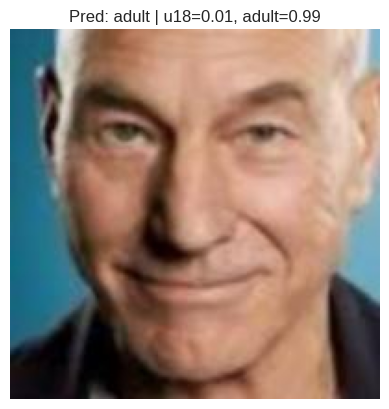


Image: 24_1_2_20170116170612853.jpg.chip.jpg
Prediction: ADULT
Prob under18: 0.0919
Prob adult:   0.9081


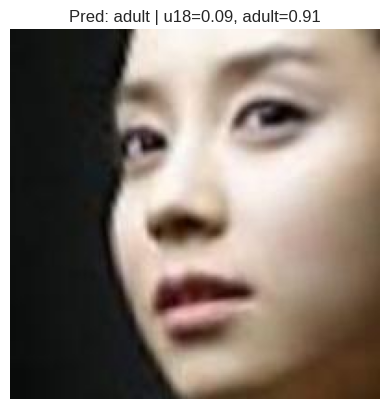


Image: 29_0_3_20170117180739306.jpg.chip.jpg
Prediction: ADULT
Prob under18: 0.2806
Prob adult:   0.7194


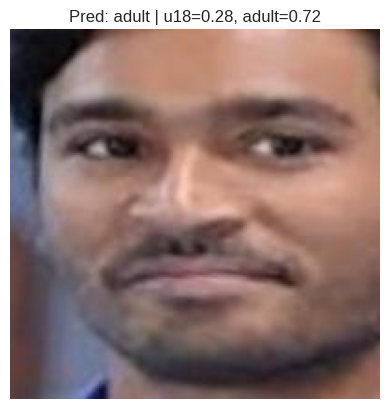


Image: 1_1_2_20161219211002173.jpg.chip.jpg
Prediction: UNDER18
Prob under18: 1.0000
Prob adult:   0.0000


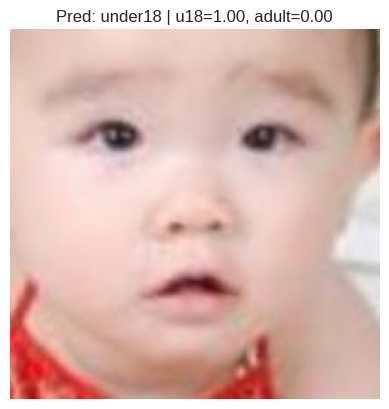


Image: 30_1_3_20170119204037590.jpg.chip.jpg
Prediction: ADULT
Prob under18: 0.0903
Prob adult:   0.9097


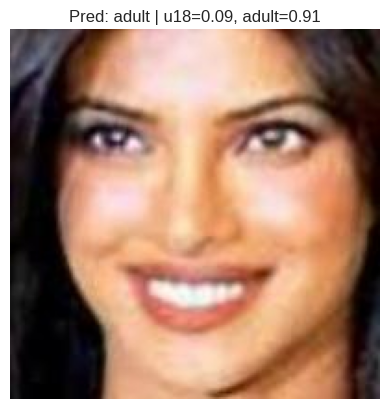


Image: 1_0_2_20161219153318900.jpg.chip.jpg
Prediction: UNDER18
Prob under18: 0.9994
Prob adult:   0.0006


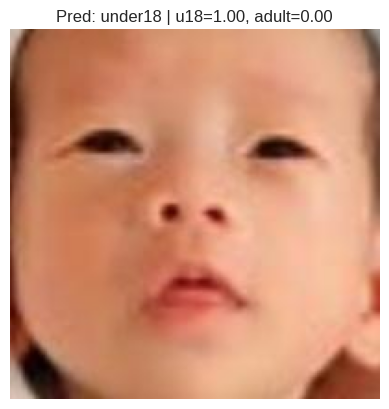


Image: 8_1_4_20161223230041764.jpg.chip.jpg
Prediction: UNDER18
Prob under18: 0.7074
Prob adult:   0.2926


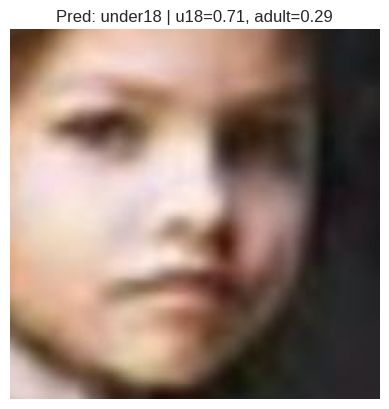

,image,path,predicted_class,prob_under18,prob_adult
0,18_1_1_20170117140201823.jpg.chip.jpg,/kaggle/input/utkface-new/UTKFace/18_1_1_20170...,adult,0.255544,7.444563e-01
1,43_0_0_20170104172942851.jpg.chip.jpg,/kaggle/input/utkface-new/UTKFace/43_0_0_20170...,adult,0.016852,9.831476e-01
2,10_0_0_20170110225414790.jpg.chip.jpg,/kaggle/input/utkface-new/UTKFace/10_0_0_20170...,under18,1.000000,1.161803e-07
3,63_0_0_20170117194914689.jpg.chip.jpg,/kaggle/input/utkface-new/UTKFace/63_0_0_20170...,adult,0.007338,9.926621e-01
4,24_1_2_20170116170612853.jpg.chip.jpg,/kaggle/input/utkface-new/UTKFace/24_1_2_20170...,adult,0.091935,9.080651e-01
5,29_0_3_20170117180739306.jpg.chip.jpg,/kaggle/input/utkface-new/UTKFace/29_0_3_20170...,adult,0.280590,7.194099e-01
6,1_1_2_20161219211002173.jpg.chip.jpg,/kaggle/input/utkface-new/UTKFace/1_1_2_201612...,under18,0.999998,2.260613e-06
7,30_1_3_20170119204037590.jpg.chip.jpg,/kaggle/input/utkface-new/UTKFace/30_1_3_20170...,adult,0.090291,9.097086e-01
8,1_0_2_20161219153318900.jpg.chip.jpg,/kaggle/input/utkface-new/crop_part1/1_0_2_201...,under18,0.999400,5.999772e-04
9,8_1_4_20161223230041764.jpg.chip.jpg,/kaggle/input/utkface-new/crop_part1/8_1_4_201...,under18,0.707390,2.926103e-01


In [29]:
infer_auto(n_samples=10, show=True)


# PHASE 2: FAIRFACE FINE-TUNING

## Fine-tuning Phase 1 Model on FairFace Dataset

**Goals:**
- Improve detection of very young children (0-10 years)
- Better robustness to real-world conditions
- Maintain Phase 1 performance while specializing for young children

**Key Changes:**
- Load Phase 1 best model (not ImageNet)
- Freeze early layers (prevent catastrophic forgetting)
- Lower learning rate (0.0001 vs 0.002)
- Fewer epochs (30 vs 60)
- Higher class weight for Under-18 (2.0 vs 1.5)

---


## Phase 2 Step 1: Configuration & FairFace Dataset Loading


In [ ]:
# ============================================================
# PHASE 2: CONFIGURATION
# ============================================================

class Phase2Config:
    """Phase 2 Fine-tuning Configuration"""
    
    # FairFace dataset paths
    FAIRFACE_TRAIN_DIR = '/kaggle/input/fairface/FairFace/train'
    FAIRFACE_VAL_DIR = '/kaggle/input/fairface/FairFace/val'
    FAIRFACE_TRAIN_CSV = '/kaggle/input/fairface/FairFace/train_labels.csv'
    FAIRFACE_VAL_CSV = '/kaggle/input/fairface/FairFace/val_labels.csv'
    
    # Phase 1 model path (from Kaggle input dataset)
    PHASE1_CHECKPOINT = '/kaggle/input/model1/pytorch/default/1/best_model.pth'
    PHASE1_WEIGHTS = '/kaggle/input/model1/pytorch/default/1/best_model.pt'  # Alternative weights-only path
    
    # Output directory
    OUTPUT_DIR = '/kaggle/working/phase2/'
    
    # Image settings (same as Phase 1)
    IMAGE_SIZE = 584
    
    # Model settings
    MODEL_NAME = 'efficientnet_b3'
    NUM_CLASSES = 2
    
    # Fine-tuning settings
    BATCH_SIZE = 32  # Per GPU (same as Phase 1)
    NUM_EPOCHS = 30  # Fewer epochs for fine-tuning
    BASE_LEARNING_RATE = 0.0001  # 10x smaller than Phase 1
    WEIGHT_DECAY = 0.0001
    
    # Data split
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    
    # DataLoader
    NUM_WORKERS = 4
    PIN_MEMORY = True
    
    # Optimizer & Scheduler
    SCHEDULER_PATIENCE = 5
    SCHEDULER_FACTOR = 0.5
    SCHEDULER_MIN_LR = 1e-7
    
    # Early stopping
    EARLY_STOPPING_PATIENCE = 8  # Shorter patience
    
    # Mixed precision
    USE_AMP = True
    
    # Checkpointing
    METRIC_TO_MONITOR = 'val_under18_recall'
    
    # Class names
    CLASS_NAMES = ['under18', 'adult']
    
    # Age threshold
    AGE_THRESHOLD = 18
    
    # Class weights (higher emphasis on Under-18)
    CLASS_WEIGHTS = [2.0, 1.0]  # [under18, adult] - increased from [1.5, 1.0]
    
    # Layer freezing
    FREEZE_RATIO = 0.5  # Freeze first 50% of backbone layers
    
    def __init__(self, num_gpus=1):
        """Initialize with GPU-aware LR scaling"""
        self.LEARNING_RATE = self.BASE_LEARNING_RATE * num_gpus

# Get number of GPUs directly (don't rely on world_size)
num_gpus_phase2 = torch.cuda.device_count() if torch.cuda.is_available() else 1

# Check if use_ddp, rank, local_rank, device are defined (from Phase 1), otherwise determine from environment
if 'use_ddp' not in globals():
    # Check if DDP environment variables are set
    use_ddp = 'RANK' in os.environ and 'WORLD_SIZE' in os.environ and 'LOCAL_RANK' in os.environ
    if use_ddp:
        rank = int(os.environ.get('RANK', 0))
        local_rank = int(os.environ.get('LOCAL_RANK', 0))
        device = torch.device(f'cuda:{local_rank}')
    else:
        rank = 0
        local_rank = 0
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
else:
    # Use existing values from Phase 1 if they exist
    if 'rank' not in globals():
        rank = 0
    if 'local_rank' not in globals():
        local_rank = 0
    if 'device' not in globals():
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Initialize Phase 2 config
phase2_config = Phase2Config(num_gpus=num_gpus_phase2)

# Create output directory
os.makedirs(phase2_config.OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(phase2_config.OUTPUT_DIR, 'checkpoints'), exist_ok=True)

print("="*60)
print("PHASE 2 CONFIGURATION")
print("="*60)
print(f"Image Size: {phase2_config.IMAGE_SIZE}×{phase2_config.IMAGE_SIZE}")
print(f"Batch Size: {phase2_config.BATCH_SIZE} (per GPU)")
print(f"Total Batch Size: {phase2_config.BATCH_SIZE * num_gpus_phase2} (with {num_gpus_phase2} GPUs)")
print(f"Epochs: {phase2_config.NUM_EPOCHS}")
print(f"Base Learning Rate: {phase2_config.BASE_LEARNING_RATE} (10× smaller than Phase 1)")
print(f"Scaled Learning Rate: {phase2_config.LEARNING_RATE} (×{num_gpus_phase2} for {num_gpus_phase2} GPUs)")
print(f"Class Weights: Under-18={phase2_config.CLASS_WEIGHTS[0]}, Adult={phase2_config.CLASS_WEIGHTS[1]}")
print(f"Freeze Ratio: {phase2_config.FREEZE_RATIO*100:.0f}% of backbone layers")
print(f"Phase 1 Checkpoint: {phase2_config.PHASE1_CHECKPOINT}")
training_mode_phase2 = 'DDP' if (num_gpus_phase2 > 1 and use_ddp) else ('DataParallel' if num_gpus_phase2 > 1 else 'Single GPU')
print(f"Training Mode: {training_mode_phase2}")
print("="*60)


In [ ]:
# ============================================================
# PHASE 2: LOAD FAIRFACE DATASET
# ============================================================

print("="*60)
print("LOADING FAIRFACE DATASET")
print("="*60)

# Check FairFace paths
fairface_paths_exist = {
    'train_dir': os.path.exists(phase2_config.FAIRFACE_TRAIN_DIR),
    'val_dir': os.path.exists(phase2_config.FAIRFACE_VAL_DIR),
    'train_csv': os.path.exists(phase2_config.FAIRFACE_TRAIN_CSV),
    'val_csv': os.path.exists(phase2_config.FAIRFACE_VAL_CSV)
}

for key, exists in fairface_paths_exist.items():
    status = "✓" if exists else "❌"
    print(f"{status} {key}: {exists}")

if not all(fairface_paths_exist.values()):
    print("\n⚠ Some FairFace paths not found. Checking alternatives...")
    if os.path.exists('/kaggle/input/'):
        print("Available datasets:")
        for item in os.listdir('/kaggle/input/'):
            print(f"  - /kaggle/input/{item}")

# Load FairFace CSV files
print("\nLoading FairFace labels...")

try:
    fairface_train_df = pd.read_csv(phase2_config.FAIRFACE_TRAIN_CSV)
    fairface_val_df = pd.read_csv(phase2_config.FAIRFACE_VAL_CSV)
    
    print(f"✓ Train CSV loaded: {len(fairface_train_df):,} rows")
    print(f"✓ Val CSV loaded: {len(fairface_val_df):,} rows")
    
    # Display column names
    print(f"\nTrain CSV columns: {list(fairface_train_df.columns)}")
    print(f"Val CSV columns: {list(fairface_val_df.columns)}")
    
    # Display sample rows
    print(f"\nSample train data:")
    print(fairface_train_df.head())
    
except Exception as e:
    print(f"❌ Error loading FairFace CSVs: {e}")
    fairface_train_df = None
    fairface_val_df = None

print("="*60)


In [ ]:
# ============================================================
# PHASE 2: PARSE FAIRFACE DATA
# ============================================================

def parse_fairface_age(age_str):
    """
    Parse FairFace age format (e.g., "0-2", "3-9", "10-19", "50-59", "9-Mar", "19-Oct")
    Handles various formats including month abbreviations that seem to be typos.
    Returns: (min_age, max_age, label)
    """
    try:
        age_str = str(age_str).strip()
        
        # Handle range format like "0-2", "10-19", "50-59"
        if '-' in age_str and age_str[0].isdigit():
            parts = age_str.split('-')
            if len(parts) == 2 and parts[0].isdigit() and parts[1].isdigit():
                min_age = int(parts[0])
                max_age = int(parts[1])
            # Handle typos like "9-Mar" (probably meant "3-9") or "19-Oct" (probably meant "10-19")
            elif len(parts) == 2 and parts[0].isdigit() and not parts[1].isdigit():
                # Try to interpret month abbreviations as age ranges
                first_num = int(parts[0])
                if first_num == 9:
                    # "9-Mar" likely means "3-9"
                    min_age, max_age = 3, 9
                elif first_num == 19:
                    # "19-Oct" likely means "10-19"
                    min_age, max_age = 10, 19
                else:
                    return None
            else:
                return None
        # Handle single age values
        elif age_str.isdigit():
            min_age = max_age = int(age_str)
        else:
            return None
        
        # Create binary label
        label = 0 if max_age < phase2_config.AGE_THRESHOLD else 1
        label_name = phase2_config.CLASS_NAMES[label]
        
        # Use average age for representation
        avg_age = (min_age + max_age) / 2
        
        return {
            'min_age': min_age,
            'max_age': max_age,
            'avg_age': avg_age,
            'label': label,
            'label_name': label_name
        }
    except Exception as e:
        return None

print("Parsing FairFace data...")

# Process training data
phase2_data_list = []

if fairface_train_df is not None:
    # Check CSV structure - FairFace typically has 'file', 'age', etc.
    csv_columns = fairface_train_df.columns.tolist()
    
    # Find age and file columns (handle different naming)
    age_col = None
    file_col = None
    
    for col in csv_columns:
        if 'age' in col.lower():
            age_col = col
        if 'file' in col.lower() or 'image' in col.lower() or 'path' in col.lower():
            file_col = col
    
    if age_col is None or file_col is None:
        print(f"⚠ Could not find age/file columns. Available: {csv_columns}")
        print("Trying common patterns...")
        # Try common patterns
        if 'age' in csv_columns:
            age_col = 'age'
        if 'file' in csv_columns:
            file_col = 'file'
        elif 'file_name' in csv_columns:
            file_col = 'file_name'
        elif 'image' in csv_columns:
            file_col = 'image'
    
    if age_col and file_col:
        print(f"Using columns: age='{age_col}', file='{file_col}'")
        
        files_found = 0
        files_not_found = 0
        sample_missing_files = []
        
        for idx, row in tqdm(fairface_train_df.iterrows(), total=len(fairface_train_df), desc="Processing FairFace train"):
            age_info = parse_fairface_age(str(row[age_col]))
            if age_info:
                filename = str(row[file_col]).strip()
                
                # Try multiple path combinations
                filepath = None
                
                # Option 1: Direct path from CSV (if it's already a full path)
                if os.path.exists(filename):
                    filepath = filename
                # Option 2: CSV has "train/1.jpg" format - strip "train/" prefix and join with train directory
                elif filename.startswith('train/'):
                    # Remove "train/" prefix and join with train directory
                    relative_path = filename.replace('train/', '', 1)
                    potential_path = os.path.join(phase2_config.FAIRFACE_TRAIN_DIR, relative_path)
                    if os.path.exists(potential_path):
                        filepath = potential_path
                    # Also try with just basename in case files are directly in train folder
                    elif os.path.exists(os.path.join(phase2_config.FAIRFACE_TRAIN_DIR, os.path.basename(relative_path))):
                        filepath = os.path.join(phase2_config.FAIRFACE_TRAIN_DIR, os.path.basename(relative_path))
                # Option 3: Join with train directory (CSV has just filename)
                elif os.path.exists(os.path.join(phase2_config.FAIRFACE_TRAIN_DIR, filename)):
                    filepath = os.path.join(phase2_config.FAIRFACE_TRAIN_DIR, filename)
                # Option 4: Try with just the basename (in case CSV has subdirectory paths)
                elif os.path.exists(os.path.join(phase2_config.FAIRFACE_TRAIN_DIR, os.path.basename(filename))):
                    filepath = os.path.join(phase2_config.FAIRFACE_TRAIN_DIR, os.path.basename(filename))
                # Option 5: Check if CSV has subdirectory structure - search recursively
                else:
                    # Try to find the file by searching in subdirectories
                    base_name = os.path.basename(filename)
                    for root, dirs, files in os.walk(phase2_config.FAIRFACE_TRAIN_DIR):
                        if base_name in files:
                            filepath = os.path.join(root, base_name)
                            break
                
                # Check if file exists
                if filepath and os.path.exists(filepath):
                    phase2_data_list.append({
                        'filename': os.path.basename(filename),
                        'filepath': filepath,
                        'age': age_info['avg_age'],
                        'min_age': age_info['min_age'],
                        'max_age': age_info['max_age'],
                        'label': age_info['label'],
                        'label_name': age_info['label_name'],
                        'source': 'fairface'
                    })
                    files_found += 1
                else:
                    files_not_found += 1
                    if len(sample_missing_files) < 5:
                        sample_missing_files.append({
                            'csv_filename': filename,
                            'tried_path': os.path.join(phase2_config.FAIRFACE_TRAIN_DIR, filename) if filepath is None else filepath
                        })
        
        # Print debugging info
        if files_not_found > 0 and files_found == 0:
            print(f"\n[WARNING] Found {files_found} files, {files_not_found} files not found")
            print(f"Sample missing files (first 5):")
            for item in sample_missing_files:
                print(f"  CSV filename: {item['csv_filename']}")
                print(f"  Tried path: {item['tried_path']}")
                print(f"  Exists: {os.path.exists(item['tried_path'])}")
            
            # Check what files actually exist in the directory
            if os.path.exists(phase2_config.FAIRFACE_TRAIN_DIR):
                actual_files = [f for f in os.listdir(phase2_config.FAIRFACE_TRAIN_DIR) 
                               if f.endswith(('.jpg', '.jpeg', '.png'))]
                print(f"\nActual files in {phase2_config.FAIRFACE_TRAIN_DIR}: {len(actual_files)}")
                if len(actual_files) > 0:
                    print(f"Sample actual files (first 5):")
                    for f in actual_files[:5]:
                        print(f"  - {f}")
            
            # Check CSV sample filenames
            print(f"\nSample CSV filenames (first 5):")
            for i, row in fairface_train_df.head(5).iterrows():
                print(f"  - {row[file_col]}")
    else:
        print("[ERROR] Could not determine CSV structure. Please check FairFace CSV format.")
        print(f"Available columns: {csv_columns}")
        print("Expected columns: 'age' (or similar) and 'file'/'file_name'/'image' (or similar)")
else:
    print("[ERROR] fairface_train_df is None. Please check FairFace CSV loading in previous cell.")

print(f"\n[OK] Processed {len(phase2_data_list):,} FairFace training images")

# Create DataFrame (always create, even if empty)
if len(phase2_data_list) > 0:
    phase2_df = pd.DataFrame(phase2_data_list)
    print(f"\nFairFace class distribution:")
    print(phase2_df['label_name'].value_counts())
    
    print(f"\nFairFace age group distribution:")
    age_groups = {
        '0-2': (0, 2),
        '3-9': (3, 9),
        '10-19': (10, 19),
        '20-29': (20, 29),
        '30-39': (30, 39),
        '40-49': (40, 49),
        '50-59': (50, 59),
        '60+': (60, 200)
    }
    
    for group_name, (min_age, max_age) in age_groups.items():
        count = len(phase2_df[(phase2_df['age'] >= min_age) & (phase2_df['age'] <= max_age)])
        if count > 0:
            pct = count / len(phase2_df) * 100
            print(f"  {group_name:10s}: {count:5d} ({pct:5.2f}%)")
else:
    # Create empty DataFrame with expected columns
    phase2_df = pd.DataFrame(columns=['filename', 'filepath', 'age', 'min_age', 'max_age', 'label', 'label_name', 'source'])
    print("[WARNING] No FairFace data processed. Creating empty DataFrame.")

print("="*60)


In [ ]:
# ============================================================
# PHASE 2: ADD ADULT CONTRAST SET FROM ORIGINAL DATASET
# ============================================================

print("="*60)
print("CREATING BALANCED FINE-TUNING DATASET")
print("="*60)

# Check if phase2_df exists and has data
if 'phase2_df' not in globals() or phase2_df is None:
    raise NameError("phase2_df not found. Please run the FairFace parsing cell first.")

if len(phase2_df) == 0:
    raise ValueError("phase2_df is empty. Please check FairFace dataset loading and parsing.")

# Get FairFace Under-18 samples
fairface_under18 = phase2_df[phase2_df['label'] == 0].copy()
fairface_count = len(fairface_under18)

print(f"\nFairFace Under-18 samples: {fairface_count:,}")

if fairface_count == 0:
    print("[WARNING] No Under-18 samples found in FairFace data!")
    print("Please check the FairFace CSV format and age parsing logic.")

# Get adults from original Phase 1 dataset (if available)
# Try multiple methods to load original UTKFace adult samples
original_adults = None
load_method = None

# Method 1: Check if variables exist in memory (from Phase 1 cells)
if 'adult_df' in globals() and len(adult_df) > 0:
    original_adults = adult_df.copy()
    load_method = "Memory (adult_df)"
elif 'df' in globals() and len(df) > 0:
    original_adults = df[df['label'] == 1].copy()
    load_method = "Memory (df)"

# Method 2: Try loading from saved CSV files from Phase 1
if (original_adults is None or len(original_adults) == 0):
    # Try Phase 1 output directory (if config exists) or Phase 2 output directory
    output_dir = phase2_config.OUTPUT_DIR
    if 'config' in globals():
        output_dir = config.OUTPUT_DIR
    
    # Try loading from balanced_dataset.csv (Phase 1 output)
    balanced_csv = os.path.join(output_dir, 'balanced_dataset.csv')
    if os.path.exists(balanced_csv):
        try:
            balanced_data = pd.read_csv(balanced_csv)
            original_adults = balanced_data[balanced_data['label'] == 1].copy()
            load_method = f"CSV (balanced_dataset.csv)"
        except Exception as e:
            print(f"[Method 2] Error loading balanced_dataset.csv: {e}")

# Method 3: Try loading from train_split.csv (Phase 1 output)
if (original_adults is None or len(original_adults) == 0):
    # Try Phase 1 output directory (if config exists) or Phase 2 output directory
    output_dir = phase2_config.OUTPUT_DIR
    if 'config' in globals():
        output_dir = config.OUTPUT_DIR
    
    train_csv = os.path.join(output_dir, 'train_split.csv')
    if os.path.exists(train_csv):
        try:
            train_data = pd.read_csv(train_csv)
            original_adults = train_data[train_data['label'] == 1].copy()
            load_method = f"CSV (train_split.csv)"
        except Exception as e:
            print(f"[Method 3] Error loading train_split.csv: {e}")

# Method 4: Load directly from UTKFace dataset paths
if (original_adults is None or len(original_adults) == 0):
    utkface_paths = [
        '/kaggle/input/utkface-new/UTKFace',
        '/kaggle/input/utkface-new/crop_part1'
    ]
    
    # Try to find existing UTKFace paths
    available_paths = [p for p in utkface_paths if os.path.exists(p)]
    
    if len(available_paths) > 0:
        print(f"[Method 4] Loading directly from UTKFace dataset paths...")
        try:
            # Define parse_utkface_filename if not already defined (from Phase 1)
            if 'parse_utkface_filename' not in globals():
                def parse_utkface_filename(filename):
                    """
                    Parse UTKFace filename format: [age]_[gender]_[race]_[date].jpg
                    
                    Args:
                        filename: str, filename to parse
                        
                    Returns:
                        dict with age, gender, race, or None if parsing fails
                    """
                    try:
                        parts = filename.split('_')
                        age = int(parts[0])
                        gender = int(parts[1])  # 0=male, 1=female
                        race = int(parts[2])     # 0=white, 1=black, 2=asian, 3=indian, 4=others
                        
                        return {
                            'age': age,
                            'gender': gender,
                            'race': race
                        }
                    except:
                        return None
            
            # Collect all image files from UTKFace directories
            all_image_files = []
            for path in available_paths:
                if os.path.exists(path):
                    files = [f for f in os.listdir(path) if f.endswith(('.jpg', '.jpeg', '.png'))]
                    all_image_files.extend([os.path.join(path, f) for f in files])
            
            print(f"  Found {len(all_image_files):,} images in UTKFace directories")
            
            # Parse filenames and extract adults
            adult_data_list = []
            age_threshold = phase2_config.AGE_THRESHOLD
            for filepath in tqdm(all_image_files, desc="Parsing UTKFace", total=min(50000, len(all_image_files))):
                filename = os.path.basename(filepath)
                parsed = parse_utkface_filename(filename)
                if parsed and parsed['age'] >= age_threshold:  # Adult
                    adult_data_list.append({
                        'filename': filename,
                        'filepath': filepath,
                        'age': parsed['age'],
                        'min_age': parsed['age'],
                        'max_age': parsed['age'],
                        'label': 1,
                        'label_name': 'adult',
                        'gender': parsed['gender'],
                        'race': parsed['race']
                    })
            
            if len(adult_data_list) > 0:
                original_adults = pd.DataFrame(adult_data_list)
                load_method = f"Direct from UTKFace paths ({len(available_paths)} directories)"
                print(f"  Parsed {len(original_adults):,} adult samples from UTKFace")
            else:
                print(f"  [Method 4] No adult samples found in UTKFace directories")
                
        except Exception as e:
            print(f"[Method 4] Error loading from UTKFace paths: {e}")
            import traceback
            traceback.print_exc()

# If we found original adults, use them to balance
if original_adults is not None and len(original_adults) > 0:
    print(f"\n[OK] Original adult samples loaded via {load_method}: {len(original_adults):,} samples")
    
    # Sample same number of adults as FairFace Under-18
    target_adult_count = min(fairface_count, len(original_adults))
    
    # Get random seed (use 42 as default if not defined)
    random_seed = getattr(phase2_config, 'RANDOM_SEED', 42)
    
    adult_contrast = resample(
        original_adults,
        n_samples=target_adult_count,
        random_state=random_seed,
        replace=False
    )
    
    # Ensure required columns exist
    if 'source' not in adult_contrast.columns:
        adult_contrast['source'] = 'utkface'
    if 'min_age' not in adult_contrast.columns:
        adult_contrast['min_age'] = adult_contrast['age']
    if 'max_age' not in adult_contrast.columns:
        adult_contrast['max_age'] = adult_contrast['age']
    
    print(f"✓ Sampled {len(adult_contrast):,} adults from original UTKFace dataset")
    
    # Combine FairFace Under-18 + UTKFace Adults
    # Ensure both have same columns
    required_cols = ['filename', 'filepath', 'age', 'min_age', 'max_age', 'label', 'label_name', 'source']
    
    phase2_final_df = pd.concat([
        fairface_under18[required_cols],
        adult_contrast[required_cols]
    ], ignore_index=True)
    
    # Shuffle
    random_seed = getattr(phase2_config, 'RANDOM_SEED', 42)
    phase2_final_df = phase2_final_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)
    
    print(f"\n✓ Final Phase 2 dataset: {len(phase2_final_df):,} samples")
    print(f"\nClass distribution:")
    print(phase2_final_df['label_name'].value_counts())
    print(f"\nSource distribution:")
    print(phase2_final_df['source'].value_counts())
    
else:
    # Get output directory for warning message
    output_dir = phase2_config.OUTPUT_DIR
    if 'config' in globals():
        output_dir = config.OUTPUT_DIR
    
    print("\n[WARNING] Original UTKFace dataset not found.")
    print("  Tried methods:")
    print("    1. Variables in memory (adult_df, df)")
    print(f"    2. CSV file: {os.path.join(output_dir, 'balanced_dataset.csv')}")
    print(f"    3. CSV file: {os.path.join(output_dir, 'train_split.csv')}")
    print("    4. Direct load from UTKFace paths:")
    print("       - /kaggle/input/utkface-new/UTKFace")
    print("       - /kaggle/input/utkface-new/crop_part1")
    print("\n  Using only FairFace data (unbalanced - only Under-18 samples)")
    print("\n  Note: For balanced fine-tuning, you should:")
    print("    - Run Phase 1 cells first to create adult_df/df variables, OR")
    print("    - Ensure balanced_dataset.csv or train_split.csv exists from Phase 1, OR")
    print("    - Ensure UTKFace dataset is added to Kaggle notebook at the paths above")
    print("    - The dataset will still work but will be unbalanced (only Under-18 from FairFace)")
    phase2_final_df = fairface_under18.copy()

# Save Phase 2 dataset
phase2_final_df.to_csv(os.path.join(phase2_config.OUTPUT_DIR, 'phase2_dataset.csv'), index=False)
print(f"\n✓ Phase 2 dataset saved")
print("="*60)


In [ ]:
# ============================================================
# PHASE 2: TRAIN-VAL-TEST SPLIT
# ============================================================

print("="*60)
print("PHASE 2 TRAIN-VAL-TEST SPLIT")
print("="*60)

# Get random seed (use 42 as default if not defined)
random_seed = getattr(phase2_config, 'RANDOM_SEED', 42)

# Stratified split
phase2_train_df, phase2_temp_df = train_test_split(
    phase2_final_df,
    test_size=(phase2_config.VAL_RATIO + phase2_config.TEST_RATIO),
    stratify=phase2_final_df['label'],
    random_state=random_seed
)

phase2_val_df, phase2_test_df = train_test_split(
    phase2_temp_df,
    test_size=phase2_config.TEST_RATIO / (phase2_config.VAL_RATIO + phase2_config.TEST_RATIO),
    stratify=phase2_temp_df['label'],
    random_state=random_seed
)

print(f"\nPhase 2 splits:")
print(f"Training: {len(phase2_train_df):,} ({phase2_config.TRAIN_RATIO*100:.0f}%)")
print(phase2_train_df['label_name'].value_counts())

print(f"\nValidation: {len(phase2_val_df):,} ({phase2_config.VAL_RATIO*100:.0f}%)")
print(phase2_val_df['label_name'].value_counts())

print(f"\nTest: {len(phase2_test_df):,} ({phase2_config.TEST_RATIO*100:.0f}%)")
print(phase2_test_df['label_name'].value_counts())

# Save splits
phase2_train_df.to_csv(os.path.join(phase2_config.OUTPUT_DIR, 'phase2_train.csv'), index=False)
phase2_val_df.to_csv(os.path.join(phase2_config.OUTPUT_DIR, 'phase2_val.csv'), index=False)
phase2_test_df.to_csv(os.path.join(phase2_config.OUTPUT_DIR, 'phase2_test.csv'), index=False)

print(f"\n✓ Phase 2 splits saved")
print("="*60)


In [ ]:
# ============================================================
# PHASE 2: CREATE DATASETS & DATALOADERS
# ============================================================

print("="*60)
print("PHASE 2 DATASETS & DATALOADERS")
print("="*60)

# Reuse same transforms from Phase 1 (or define if not available)
if 'train_transforms' in globals() and 'val_transforms' in globals():
    phase2_train_transforms = train_transforms
    phase2_val_transforms = val_transforms
    print("[OK] Reusing transforms from Phase 1")
else:
    # Define transforms for Phase 2 (same as Phase 1)
    print("[OK] Defining transforms for Phase 2")
    phase2_train_transforms = transforms.Compose([
        # Resize to slightly larger for cropping
        transforms.Resize((640, 640)),
        
        # Random resized crop
        transforms.RandomResizedCrop(
            phase2_config.IMAGE_SIZE,  # 584×584
            scale=(0.85, 1.0),  # Crop 85-100%
            ratio=(0.95, 1.05)  # Near-square
        ),
        
        # Random horizontal flip
        transforms.RandomHorizontalFlip(p=0.5),
        
        # Random rotation
        transforms.RandomRotation(
            degrees=12,
            fill=0
        ),
        
        # Color augmentation
        transforms.ColorJitter(
            brightness=0.25,
            contrast=0.25,
            saturation=0.20,
            hue=0.05
        ),
        
        # Random Gaussian blur
        transforms.RandomApply([
            transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))
        ], p=0.25),
        
        # Random grayscale
        transforms.RandomGrayscale(p=0.1),
        
        # Random perspective
        transforms.RandomPerspective(
            distortion_scale=0.2,
            p=0.2
        ),
        
        # Convert to tensor
        transforms.ToTensor(),
        
        # Normalize with ImageNet stats
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        
        # Random erasing (cutout)
        transforms.RandomErasing(
            p=0.25,
            scale=(0.02, 0.15),
            ratio=(0.3, 3.3),
            value='random'
        )
    ])
    
    phase2_val_transforms = transforms.Compose([
        transforms.Resize((phase2_config.IMAGE_SIZE, phase2_config.IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    print(f"✓ Training transforms defined for {phase2_config.IMAGE_SIZE}×{phase2_config.IMAGE_SIZE}")
    print(f"✓ Validation transforms defined for {phase2_config.IMAGE_SIZE}×{phase2_config.IMAGE_SIZE}")

# Check if AgeClassificationDataset is defined (from Phase 1)
if 'AgeClassificationDataset' not in globals():
    print("[OK] Defining AgeClassificationDataset for Phase 2")
    class AgeClassificationDataset(Dataset):
        """
        Custom Dataset for age-based binary classification
        """
        
        def __init__(self, dataframe, transform=None, return_metadata=False):
            """
            Args:
                dataframe: pandas DataFrame with columns ['filepath', 'label', 'age']
                transform: torchvision transforms
                return_metadata: if True, returns (image, label, metadata)
            """
            self.dataframe = dataframe.reset_index(drop=True)
            self.transform = transform
            self.return_metadata = return_metadata
            
        def __len__(self):
            return len(self.dataframe)
        
        def __getitem__(self, idx):
            # Get row
            row = self.dataframe.iloc[idx]
            
            img_path = row['filepath']
            label = row['label']
            age = row['age']
            
            # Load image
            try:
                image = Image.open(img_path).convert('RGB')
            except Exception as e:
                # Fallback for corrupted images
                image = Image.new('RGB', (phase2_config.IMAGE_SIZE, phase2_config.IMAGE_SIZE), color=(128, 128, 128))
            
            # Apply transforms
            if self.transform:
                image = self.transform(image)
            
            if self.return_metadata:
                metadata = {
                    'filename': row.get('filename', ''),
                    'age': age,
                    'gender': row.get('gender', -1),
                    'race': row.get('race', -1)
                }
                return image, label, metadata
            else:
                return image, label
else:
    print("[OK] Using AgeClassificationDataset from Phase 1")

# Create datasets
phase2_train_dataset = AgeClassificationDataset(
    phase2_train_df,
    transform=phase2_train_transforms,
    return_metadata=False
)

phase2_val_dataset = AgeClassificationDataset(
    phase2_val_df,
    transform=phase2_val_transforms,
    return_metadata=False
)

phase2_test_dataset = AgeClassificationDataset(
    phase2_test_df,
    transform=phase2_val_transforms,
    return_metadata=True
)

print(f"[OK] Phase 2 Training dataset: {len(phase2_train_dataset):,} samples")
print(f"[OK] Phase 2 Validation dataset: {len(phase2_val_dataset):,} samples")
print(f"[OK] Phase 2 Test dataset: {len(phase2_test_dataset):,} samples")

# Get number of GPUs for Phase 2
num_gpus_phase2 = torch.cuda.device_count() if torch.cuda.is_available() else 1

# Create DistributedSampler for Phase 2 if using DDP (not needed for DataParallel)
if num_gpus_phase2 > 1 and use_ddp:
    # Get random seed (use 42 as default if not defined)
    random_seed = getattr(phase2_config, 'RANDOM_SEED', 42)
    
    # DDP requires DistributedSampler to split data across processes
    phase2_train_sampler = DistributedSampler(
        phase2_train_dataset,
        num_replicas=num_gpus_phase2,
        rank=rank,
        shuffle=True,
        seed=random_seed
    )
    phase2_val_sampler = DistributedSampler(
        phase2_val_dataset,
        num_replicas=num_gpus_phase2,
        rank=rank,
        shuffle=False
    )
    phase2_shuffle_train = False  # Sampler handles shuffling
else:
    # DataParallel or single GPU - no sampler needed
    phase2_train_sampler = None
    phase2_val_sampler = None
    phase2_shuffle_train = True

# Create DataLoaders (same setup as Phase 1)
phase2_train_loader = DataLoader(
    phase2_train_dataset,
    batch_size=phase2_config.BATCH_SIZE,
    shuffle=phase2_shuffle_train,
    sampler=phase2_train_sampler,
    num_workers=phase2_config.NUM_WORKERS,
    pin_memory=phase2_config.PIN_MEMORY,
    drop_last=True
)

phase2_val_loader = DataLoader(
    phase2_val_dataset,
    batch_size=phase2_config.BATCH_SIZE * 2,
    shuffle=False,
    sampler=phase2_val_sampler,
    num_workers=phase2_config.NUM_WORKERS,
    pin_memory=phase2_config.PIN_MEMORY,
    drop_last=False
)

phase2_test_loader = DataLoader(
    phase2_test_dataset,
    batch_size=phase2_config.BATCH_SIZE * 2,
    shuffle=False,
    num_workers=phase2_config.NUM_WORKERS,
    pin_memory=phase2_config.PIN_MEMORY,
    drop_last=False
)

if rank == 0:
    print(f"\n[OK] Phase 2 Training batches: {len(phase2_train_loader)}")
    print(f"[OK] Phase 2 Validation batches: {len(phase2_val_loader)}")
    print(f"[OK] Phase 2 Test batches: {len(phase2_test_loader)}")
    training_mode_phase2 = 'DDP' if (num_gpus_phase2 > 1 and use_ddp) else ('DataParallel' if num_gpus_phase2 > 1 else 'Single GPU')
    print(f"Phase 2 Training mode: {training_mode_phase2}")
print("="*60)


In [ ]:
# ============================================================
# PHASE 2: LOAD PHASE 1 MODEL & FREEZE LAYERS
# ============================================================

print("="*60)
print("LOADING PHASE 1 MODEL")
print("="*60)

# Check if Phase 1 checkpoint exists (try .pth first, then .pt)
phase1_checkpoint_path = None
if os.path.exists(phase2_config.PHASE1_CHECKPOINT):
    phase1_checkpoint_path = phase2_config.PHASE1_CHECKPOINT
elif os.path.exists(phase2_config.PHASE1_WEIGHTS):
    phase1_checkpoint_path = phase2_config.PHASE1_WEIGHTS
else:
    print(f"[ERROR] Phase 1 checkpoint not found at:")
    print(f"  - {phase2_config.PHASE1_CHECKPOINT}")
    print(f"  - {phase2_config.PHASE1_WEIGHTS}")
    print("Available paths:")
    if os.path.exists('/kaggle/input/model1/'):
        for root, dirs, files in os.walk('/kaggle/input/model1/'):
            for f in files:
                if f.endswith(('.pth', '.pt')):
                    print(f"  - {os.path.join(root, f)}")
    raise FileNotFoundError("Phase 1 checkpoint required for fine-tuning")

# Load Phase 1 checkpoint
if rank == 0:
    print(f"Loading Phase 1 checkpoint: {phase1_checkpoint_path}")

try:
    phase1_checkpoint = torch.load(phase1_checkpoint_path, map_location=device, weights_only=False)
except TypeError:
    phase1_checkpoint = torch.load(phase1_checkpoint_path, map_location=device)

# Handle both checkpoint format (.pth) and weights-only format (.pt)
if 'model_state_dict' in phase1_checkpoint:
    # Full checkpoint format
    phase1_model_state = phase1_checkpoint['model_state_dict']
    phase1_best_recall = phase1_checkpoint.get('best_val_recall', 0.0)
    phase1_epoch = phase1_checkpoint.get('epoch', 0)
else:
    # Weights-only format (.pt)
    phase1_model_state = phase1_checkpoint
    phase1_best_recall = 0.0  # Unknown, will be set later
    phase1_epoch = 0

if rank == 0:
    if phase1_epoch > 0:
        print(f"[OK] Phase 1 checkpoint loaded from epoch {phase1_epoch}")
        print(f"[OK] Phase 1 best Val Under-18 Recall: {phase1_best_recall*100:.2f}%")
    else:
        print(f"[OK] Phase 1 weights loaded (weights-only format)")

# Build model architecture (same as Phase 1)
# Check if config exists (from Phase 1), otherwise use pretrained=True
use_pretrained = True
if 'config' in globals() and hasattr(config, 'PRETRAINED'):
    use_pretrained = config.PRETRAINED
elif hasattr(phase2_config, 'PRETRAINED'):
    use_pretrained = phase2_config.PRETRAINED

if use_pretrained:
    weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
    phase2_model = models.efficientnet_b3(weights=weights)
else:
    phase2_model = models.efficientnet_b3(weights=None)

# Replace classifier (same structure)
num_features = phase2_model.classifier[1].in_features
phase2_model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=False),
    nn.Linear(num_features, 512),
    nn.ReLU(inplace=False),
    nn.Dropout(p=0.2, inplace=False),
    nn.Linear(512, phase2_config.NUM_CLASSES)
)

# Load Phase 1 weights
phase2_model.load_state_dict(phase1_model_state)

if rank == 0:
    print(f"[OK] Phase 1 weights loaded into model")

# Freeze early layers
def freeze_layers(model, freeze_ratio=0.5):
    """Freeze first freeze_ratio% of backbone layers"""
    # Get all layers in the feature extractor
    features = list(model.features)
    num_layers = len(features)
    freeze_until = int(num_layers * freeze_ratio)
    
    frozen_count = 0
    trainable_count = 0
    
    # Freeze early layers
    for i in range(freeze_until):
        for param in features[i].parameters():
            param.requires_grad = False
        frozen_count += 1
    
    # Keep later layers trainable
    for i in range(freeze_until, num_layers):
        for param in features[i].parameters():
            param.requires_grad = True
        trainable_count += 1
    
    # Classifier is always trainable
    for param in model.classifier.parameters():
        param.requires_grad = True
    
    return frozen_count, trainable_count

frozen_layers, trainable_layers = freeze_layers(phase2_model, phase2_config.FREEZE_RATIO)

if rank == 0:
    print(f"\n✓ Layer freezing applied:")
    print(f"  Frozen layers: {frozen_layers} (first {phase2_config.FREEZE_RATIO*100:.0f}%)")
    print(f"  Trainable layers: {trainable_layers} (last {100-phase2_config.FREEZE_RATIO*100:.0f}% + classifier)")

# Count parameters
def count_trainable_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_trainable_params(phase2_model)

if rank == 0:
    print(f"\nModel parameters:")
    print(f"  Total: {total_params:,}")
    print(f"  Trainable: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
    print(f"  Frozen: {total_params - trainable_params:,} ({(total_params-trainable_params)/total_params*100:.1f}%)")

# Move to device and apply DDP or DataParallel
phase2_model = phase2_model.to(device)

# Get number of GPUs for Phase 2
num_gpus_phase2 = torch.cuda.device_count() if torch.cuda.is_available() else 1

# Use DDP or DataParallel for multi-GPU (same logic as Phase 1)
if num_gpus_phase2 > 1:
    if use_ddp:
        # Proper DDP (requires environment variables)
        phase2_model = DDP(phase2_model, device_ids=[local_rank], output_device=local_rank, find_unused_parameters=False)
        if rank == 0:
            print(f"\n[OK] Phase 2 using DDP with {num_gpus_phase2} GPUs")
    else:
        # DataParallel (notebook-friendly, works without env vars)
        phase2_model = nn.DataParallel(phase2_model)
        if rank == 0:
            print(f"\n[OK] Phase 2 using DataParallel with {num_gpus_phase2} GPUs (notebook mode)")
else:
    if rank == 0:
        print(f"\n[OK] Phase 2 using single GPU: {device}")

print("="*60)


In [ ]:
# ============================================================
# PHASE 2: LOSS FUNCTION & OPTIMIZER
# ============================================================

print("="*60)
print("PHASE 2 LOSS FUNCTION & OPTIMIZER")
print("="*60)

# Get model parameters (unwrap DDP or DataParallel if needed)
if isinstance(phase2_model, (DDP, nn.DataParallel)):
    phase2_model_params = phase2_model.module.parameters()
else:
    phase2_model_params = phase2_model.parameters()

# Class weights (higher emphasis on Under-18)
phase2_class_weights = torch.tensor(phase2_config.CLASS_WEIGHTS).to(device)

# Loss function
phase2_criterion = nn.CrossEntropyLoss(weight=phase2_class_weights)

# Optimizer (only trainable parameters)
trainable_params = [p for p in phase2_model_params if p.requires_grad]
phase2_optimizer = optim.AdamW(
    trainable_params,
    lr=phase2_config.LEARNING_RATE,
    weight_decay=phase2_config.WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

# Learning rate scheduler
phase2_scheduler = ReduceLROnPlateau(
    phase2_optimizer,
    mode='max',
    factor=phase2_config.SCHEDULER_FACTOR,
    patience=phase2_config.SCHEDULER_PATIENCE,
    verbose=(rank == 0),
    min_lr=phase2_config.SCHEDULER_MIN_LR
)

# Mixed precision scaler
if phase2_config.USE_AMP:
    phase2_scaler = torch.cuda.amp.GradScaler()
    if rank == 0:
        print("✓ Mixed Precision (FP16) enabled")
else:
    phase2_scaler = None

if rank == 0:
    print(f"✓ Loss function: Weighted CrossEntropyLoss")
    print(f"  Class weights: Under-18={phase2_class_weights[0].item()}, Adult={phase2_class_weights[1].item()}")
    print(f"✓ Optimizer: AdamW")
    print(f"  Learning Rate: {phase2_config.LEARNING_RATE} (10× smaller than Phase 1)")
    print(f"  Weight decay: {phase2_config.WEIGHT_DECAY}")
    print(f"✓ Scheduler: ReduceLROnPlateau")
    print(f"  Patience: {phase2_config.SCHEDULER_PATIENCE} epochs")
print("="*60)


In [ ]:
# ============================================================
# PHASE 2: TRAINING LOOP
# ============================================================

# Training history
phase2_history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_under18_recall': [],
    'val_adult_recall': [],
    'learning_rate': []
}

# Best model tracking
phase2_best_val_recall = 0.0
phase2_best_epoch = 0
phase2_patience_counter = 0

phase2_checkpoint_dir = os.path.join(phase2_config.OUTPUT_DIR, 'checkpoints')
os.makedirs(phase2_checkpoint_dir, exist_ok=True)

# Define calculate_metrics function if not already defined (from Phase 1)
if 'calculate_metrics' not in globals():
    def calculate_metrics(y_true, y_pred):
        """Calculate classification metrics"""
        accuracy = accuracy_score(y_true, y_pred)
        
        # Per-class metrics
        precision_per_class = precision_score(y_true, y_pred, average=None, zero_division=0)
        recall_per_class = recall_score(y_true, y_pred, average=None, zero_division=0)
        f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)
        
        # Overall metrics
        precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
        recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
        f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
        
        return {
            'accuracy': accuracy,
            'under18_precision': precision_per_class[0],
            'under18_recall': recall_per_class[0],
            'under18_f1': f1_per_class[0],
            'adult_precision': precision_per_class[1],
            'adult_recall': recall_per_class[1],
            'adult_f1': f1_per_class[1],
            'macro_precision': precision_macro,
            'macro_recall': recall_macro,
            'macro_f1': f1_macro
        }

# Define print_metrics function if not already defined (from Phase 1)
if 'print_metrics' not in globals():
    def print_metrics(metrics, prefix=""):
        """Pretty print metrics"""
        print(f"\n{prefix}Metrics:")
        print(f"  Accuracy: {metrics['accuracy']*100:.2f}%")
        print(f"  Under-18: Precision={metrics['under18_precision']*100:.2f}%, "
              f"Recall={metrics['under18_recall']*100:.2f}%, F1={metrics['under18_f1']:.4f}")
        print(f"  Adult: Precision={metrics['adult_precision']*100:.2f}%, "
              f"Recall={metrics['adult_recall']*100:.2f}%, F1={metrics['adult_f1']:.4f}")

if rank == 0:
    print("="*60)
    print("PHASE 2 TRAINING STARTING")
    print("="*60)
    print(f"Total epochs: {phase2_config.NUM_EPOCHS}")
    print(f"Early stopping patience: {phase2_config.EARLY_STOPPING_PATIENCE}")
    print(f"Monitoring metric: {phase2_config.METRIC_TO_MONITOR}")
    if phase1_epoch > 0:
        print(f"Phase 1 baseline recall: {phase1_best_recall*100:.2f}%")
    else:
        print(f"Phase 1 baseline recall: Unknown (weights-only checkpoint)")
    print("="*60)

# Training loop
for epoch in range(phase2_config.NUM_EPOCHS):
    epoch_start_time = time.time()
    
    # Set epoch for DistributedSampler (only needed for DDP)
    num_gpus_phase2 = torch.cuda.device_count() if torch.cuda.is_available() else 1
    if num_gpus_phase2 > 1 and use_ddp and phase2_train_sampler is not None:
        phase2_train_sampler.set_epoch(epoch)
    
    # ========== TRAINING PHASE ==========
    phase2_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    all_train_preds = []
    all_train_labels = []
    
    train_pbar = tqdm(phase2_train_loader, desc=f'Phase2 Epoch {epoch+1}/{phase2_config.NUM_EPOCHS} [Train]', 
                      disable=(rank != 0))
    
    for batch_idx, (images, labels) in enumerate(train_pbar):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        phase2_optimizer.zero_grad()
        
        if phase2_config.USE_AMP:
            with torch.cuda.amp.autocast():
                outputs = phase2_model(images)
                loss = phase2_criterion(outputs, labels)
            
            phase2_scaler.scale(loss).backward()
            phase2_scaler.step(phase2_optimizer)
            phase2_scaler.update()
        else:
            outputs = phase2_model(images)
            loss = phase2_criterion(outputs, labels)
            loss.backward()
            phase2_optimizer.step()
        
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())
        
        if rank == 0:
            train_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100*train_correct/train_total:.2f}%'
            })
    
    train_loss /= len(phase2_train_loader)
    train_acc = train_correct / train_total
    
    # ========== VALIDATION PHASE ==========
    phase2_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    all_val_preds = []
    all_val_labels = []
    
    val_pbar = tqdm(phase2_val_loader, desc=f'Phase2 Epoch {epoch+1}/{phase2_config.NUM_EPOCHS} [Val]', 
                    disable=(rank != 0))
    
    with torch.no_grad():
        for images, labels in val_pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            if phase2_config.USE_AMP:
                with torch.cuda.amp.autocast():
                    outputs = phase2_model(images)
                    loss = phase2_criterion(outputs, labels)
            else:
                outputs = phase2_model(images)
                loss = phase2_criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            all_val_preds.extend(predicted.cpu().numpy())
            all_val_labels.extend(labels.cpu().numpy())
            
            if rank == 0:
                val_pbar.set_postfix({
                    'loss': f'{loss.item():.4f}',
                    'acc': f'{100*val_correct/val_total:.2f}%'
                })
    
    val_loss /= len(phase2_val_loader)
    val_acc = val_correct / val_total
    
    # Calculate metrics
    if rank == 0:
        val_metrics = calculate_metrics(all_val_labels, all_val_preds)
        val_under18_recall = val_metrics['under18_recall']
        
        # Update history
        phase2_history['train_loss'].append(train_loss)
        phase2_history['train_acc'].append(train_acc)
        phase2_history['val_loss'].append(val_loss)
        phase2_history['val_acc'].append(val_acc)
        phase2_history['val_under18_recall'].append(val_under18_recall)
        phase2_history['val_adult_recall'].append(val_metrics['adult_recall'])
        phase2_history['learning_rate'].append(phase2_optimizer.param_groups[0]['lr'])
        
        phase2_scheduler.step(val_under18_recall)
        
        # Checkpoint saving
        is_best = val_under18_recall > phase2_best_val_recall
        if is_best:
            phase2_best_val_recall = val_under18_recall
            phase2_best_epoch = epoch + 1
            phase2_patience_counter = 0
            
            # Unwrap DDP or DataParallel if needed
            if isinstance(phase2_model, (DDP, nn.DataParallel)):
                model_state = phase2_model.module.state_dict()
            else:
                model_state = phase2_model.state_dict()
            
            checkpoint = {
                'epoch': epoch + 1,
                'model_state_dict': model_state,
                'optimizer_state_dict': phase2_optimizer.state_dict(),
                'scheduler_state_dict': phase2_scheduler.state_dict(),
                'best_val_recall': phase2_best_val_recall,
                'val_metrics': val_metrics,
                'phase1_baseline': phase1_best_recall,
                'config': phase2_config.__dict__
            }
            
            torch.save(checkpoint, os.path.join(phase2_checkpoint_dir, 'best_model.pth'))
            print(f"\n✓ Best model saved! Val Under-18 Recall: {phase2_best_val_recall*100:.2f}%")
        else:
            phase2_patience_counter += 1
        
        # Epoch summary
        epoch_time = time.time() - epoch_start_time
        improvement = phase2_best_val_recall - phase1_best_recall
        
        print(f"\n{'='*60}")
        print(f"Phase 2 Epoch {epoch+1}/{phase2_config.NUM_EPOCHS} Summary")
        print(f"{'='*60}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
        print_metrics(val_metrics, prefix="Val ")
        print(f"Learning Rate: {phase2_optimizer.param_groups[0]['lr']:.6f}")
        print(f"Time: {epoch_time:.2f}s")
        print(f"Best Epoch: {phase2_best_epoch} (Recall: {phase2_best_val_recall*100:.2f}%)")
        print(f"vs Phase 1: {improvement*100:+.2f}% improvement")
        print(f"Early Stopping: {phase2_patience_counter}/{phase2_config.EARLY_STOPPING_PATIENCE}")
        print(f"{'='*60}\n")
        
        # Early stopping
        if phase2_patience_counter >= phase2_config.EARLY_STOPPING_PATIENCE:
            print(f"\n⚠ Early stopping triggered!")
            print(f"Best model was at epoch {phase2_best_epoch} with Val Under-18 Recall: {phase2_best_val_recall*100:.2f}%")
            break
    
    # Synchronize all processes (only needed for DDP)
    num_gpus_phase2 = torch.cuda.device_count() if torch.cuda.is_available() else 1
    if num_gpus_phase2 > 1 and use_ddp:
        dist.barrier()

if rank == 0:
    print("\n" + "="*60)
    print("PHASE 2 TRAINING COMPLETED")
    print("="*60)
    print(f"Best epoch: {phase2_best_epoch}")
    print(f"Best Val Under-18 Recall: {phase2_best_val_recall*100:.2f}%")
    print(f"Phase 1 baseline: {phase1_best_recall*100:.2f}%")
    print(f"Improvement: {(phase2_best_val_recall - phase1_best_recall)*100:+.2f}%")
    print("="*60)


## Phase 2: Test Evaluation & Comparison


In [ ]:
# ============================================================
# PHASE 2: LOAD BEST MODEL & TEST EVALUATION
# ============================================================

if rank == 0:
    print("="*60)
    print("PHASE 2: LOADING BEST MODEL")
    print("="*60)
    
    # Load Phase 2 best checkpoint
    phase2_checkpoint_path = os.path.join(phase2_checkpoint_dir, 'best_model.pth')
    
    try:
        phase2_checkpoint = torch.load(phase2_checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        phase2_checkpoint = torch.load(phase2_checkpoint_path, map_location=device)
    
    # Load model state
    if isinstance(phase2_model, nn.DataParallel):
        phase2_model.module.load_state_dict(phase2_checkpoint['model_state_dict'])
    else:
        phase2_model.load_state_dict(phase2_checkpoint['model_state_dict'])
    
    print(f"✓ Phase 2 best model loaded from epoch {phase2_checkpoint['epoch']}")
    print(f"✓ Phase 2 best Val Under-18 Recall: {phase2_checkpoint['best_val_recall']*100:.2f}%")
    print(f"✓ Phase 1 baseline: {phase2_checkpoint['phase1_baseline']*100:.2f}%")
    
    # Test evaluation
    print("\n" + "="*60)
    print("PHASE 2 TEST SET EVALUATION")
    print("="*60)
    
    phase2_model.eval()
    all_test_preds = []
    all_test_labels = []
    all_test_metadata = []
    
    test_pbar = tqdm(phase2_test_loader, desc='Phase 2 Testing')
    
    with torch.no_grad():
        for images, labels, metadata in test_pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            if phase2_config.USE_AMP:
                with torch.cuda.amp.autocast():
                    outputs = phase2_model(images)
            else:
                outputs = phase2_model(images)
            
            _, predicted = torch.max(outputs.data, 1)
            
            all_test_preds.extend(predicted.cpu().numpy())
            all_test_labels.extend(labels.cpu().numpy())
            all_test_metadata.extend(metadata)
    
    # Calculate test metrics
    phase2_test_metrics = calculate_metrics(all_test_labels, all_test_preds)
    
    print("\n" + "="*60)
    print("PHASE 2 TEST SET RESULTS")
    print("="*60)
    print_metrics(phase2_test_metrics, prefix="Phase 2 Test ")
    print("="*60)
    
    # Confusion Matrix
    phase2_cm = confusion_matrix(all_test_labels, all_test_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(phase2_cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=phase2_config.CLASS_NAMES, 
                yticklabels=phase2_config.CLASS_NAMES)
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title('Phase 2 Test Set Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(phase2_config.OUTPUT_DIR, 'phase2_test_confusion_matrix.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Phase 2 confusion matrix saved")
    
    # Classification Report
    print("\n" + "="*60)
    print("PHASE 2 DETAILED CLASSIFICATION REPORT")
    print("="*60)
    print(classification_report(all_test_labels, all_test_preds, 
                                target_names=phase2_config.CLASS_NAMES, digits=4))
    print("="*60)


## Phase 2: Inference Functions


In [ ]:
# ============================================================
# PHASE 2: INFERENCE FUNCTIONS
# ============================================================

print("="*60)
print("PHASE 2 INFERENCE SETUP")
print("="*60)

# Ensure model is in eval mode
phase2_model.eval()

# Define transforms (same as validation)
phase2_inference_transform = transforms.Compose([
    transforms.Resize((phase2_config.IMAGE_SIZE, phase2_config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def phase2_predict_image(image_path, show=False, return_probs=False):
    """
    Predict under18/adult for a single image using Phase 2 model.
    
    Args:
        image_path: Path to image file
        show: If True, display the image with prediction
        return_probs: If True, return probabilities instead of just prediction
    
    Returns:
        If return_probs=False: (pred_idx, pred_name)
        If return_probs=True: (pred_idx, pred_name, probs)
    """
    try:
        img = Image.open(image_path).convert("RGB")
        img_tensor = phase2_inference_transform(img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            if phase2_config.USE_AMP:
                with torch.cuda.amp.autocast():
                    outputs = phase2_model(img_tensor)
            else:
                outputs = phase2_model(img_tensor)
            
            probs = F.softmax(outputs, dim=1).cpu().numpy()[0]
            pred_idx = int(np.argmax(probs))
            pred_name = phase2_config.CLASS_NAMES[pred_idx]
        
        if show:
            plt.figure(figsize=(8, 8))
            plt.imshow(img)
            plt.title(f"Phase 2 Prediction: {pred_name.upper()}\n"
                     f"Prob Under-18: {probs[0]:.4f} | Prob Adult: {probs[1]:.4f}", 
                     fontsize=12, fontweight='bold')
            plt.axis("off")
            plt.tight_layout()
            plt.show()
        
        if return_probs:
            return pred_idx, pred_name, probs
        else:
            return pred_idx, pred_name
            
    except Exception as e:
        print(f"❌ Error processing {image_path}: {e}")
        return None, None

def phase2_predict_batch(image_paths, show=False):
    """
    Predict for a list of image paths.
    Returns a pandas DataFrame with predictions.
    """
    results = []
    for path in tqdm(image_paths, desc="Predicting"):
        result = phase2_predict_image(path, show=show, return_probs=True)
        if result[0] is not None:
            pred_idx, pred_name, probs = result
            results.append({
                "image": os.path.basename(path),
                "path": path,
                "predicted_class": pred_name,
                "prob_under18": probs[0],
                "prob_adult": probs[1],
                "confidence": max(probs)
            })
    
    if results:
        df_results = pd.DataFrame(results)
        return df_results
    else:
        return pd.DataFrame()

def phase2_infer_from_dataset(n_samples=10, show=False):
    """
    Randomly sample images from Phase 2 test dataset and run inference.
    """
    if 'phase2_test_df' not in globals():
        print("❌ Phase 2 test dataset not found. Run Phase 2 training first.")
        return None
    
    n_samples = min(n_samples, len(phase2_test_df))
    sampled = phase2_test_df.sample(n=n_samples, random_state=np.random.randint(1, 1_000_000))
    paths = sampled["filepath"].tolist()
    
    print(f"\n🔥 PHASE 2 MODEL: {len(paths)} RANDOM IMAGES FROM TEST SET 🔥\n")
    df_pred = phase2_predict_batch(paths, show=show)
    
    # Add ground truth for comparison
    if len(df_pred) > 0:
        df_pred = df_pred.merge(
            sampled[['filename', 'label_name', 'age']],
            left_on='image',
            right_on='filename',
            how='left'
        )
        df_pred['correct'] = df_pred['predicted_class'] == df_pred['label_name']
        accuracy = df_pred['correct'].mean() * 100
        print(f"\n✓ Accuracy on sampled images: {accuracy:.2f}%")
    
    return df_pred

if rank == 0:
    print("✓ Phase 2 inference functions ready:")
    print("  - phase2_predict_image(image_path, show=False, return_probs=False)")
    print("  - phase2_predict_batch(image_paths, show=False)")
    print("  - phase2_infer_from_dataset(n_samples=10, show=False)")
    print("="*60)


## Phase 2: Quick Inference Test


In [ ]:
# ============================================================
# PHASE 2: QUICK INFERENCE TEST
# ============================================================

if rank == 0:
    # Test inference on a few random images from Phase 2 test set
    print("Testing Phase 2 inference on random test images...\n")
    phase2_infer_from_dataset(n_samples=5, show=True)


## Phase 2: Save Final Model


In [ ]:
# ============================================================
# PHASE 2: SAVE FINAL MODEL
# ============================================================

if rank == 0:
    print("="*60)
    print("SAVING PHASE 2 FINAL MODEL")
    print("="*60)
    
    # Create export directory
    phase2_export_dir = os.path.join(phase2_config.OUTPUT_DIR, "final_export")
    os.makedirs(phase2_export_dir, exist_ok=True)
    
    # Unwrap DDP or DataParallel if needed
    if isinstance(phase2_model, (DDP, nn.DataParallel)):
        model_to_save = phase2_model.module
    else:
        model_to_save = phase2_model
    
    # Save weights only
    phase2_weights_path = os.path.join(phase2_export_dir, "phase2_best_model.pt")
    torch.save(model_to_save.state_dict(), phase2_weights_path)
    print(f"✓ Phase 2 weights saved: {phase2_weights_path}")
    
    # Save full checkpoint
    phase2_checkpoint_export = {
        "model_state_dict": model_to_save.state_dict(),
        "config": phase2_config.__dict__,
        "phase1_baseline": phase2_checkpoint['phase1_baseline'],
        "phase2_best_recall": phase2_best_val_recall,
        "test_metrics": phase2_test_metrics if 'phase2_test_metrics' in globals() else None
    }
    
    phase2_checkpoint_path = os.path.join(phase2_export_dir, "phase2_best_model.pth")
    torch.save(phase2_checkpoint_export, phase2_checkpoint_path)
    print(f"✓ Phase 2 checkpoint saved: {phase2_checkpoint_path}")
    
    print("\n" + "="*60)
    print("PHASE 2 COMPLETE!")
    print("="*60)
    print(f"✓ Phase 2 model exported")
    print(f"✓ Phase 2 test metrics saved")
    print(f"✓ Ready for deployment")
    print("="*60)
